# From gradients to reliable inverse experiments

## A self-contained computational notebook

We work from particle geometry and observations to gradients, optimisation,
uncertainty and a learned initial guess. All derivations needed for the seven
executed examples, the complete numerical and plotting code, and the worked
answers are included below. External references are optional.

Prerequisites: scalar differentiation, vectors and matrix multiplication.
The examples are analytic and small linear-algebra models, adapted to
questions that arise in fracture inversion. Their successful results do not
constitute a new full fracture-inverse demonstration.

### Environment and execution

Python 3.11, NumPy, PyTorch, Matplotlib 3.7 or newer, and IPython are required.
Jupyter or another notebook reader displays the retained outputs. No local
data files, helper modules, network downloads or course checkout are needed.
Run the cells in order. This project's research executions use HPC.
Installation and queue time are separate from whole-notebook execution time.
Dependencies can be installed in an isolated environment with:

    python -m pip install numpy torch 'matplotlib>=3.7' ipython jupyter

### What to inspect

1. State the unknowns and observations before interpreting a recovery.
2. Predict each plot, run its cells, then compare with the worked explanation.
3. Keep derivative correctness, recovered parameters and computational cost
   as separate questions.
4. Full numerical arrays and check outcomes remain in the final cell's
   in-memory dictionaries, including inconvenient or negative findings.

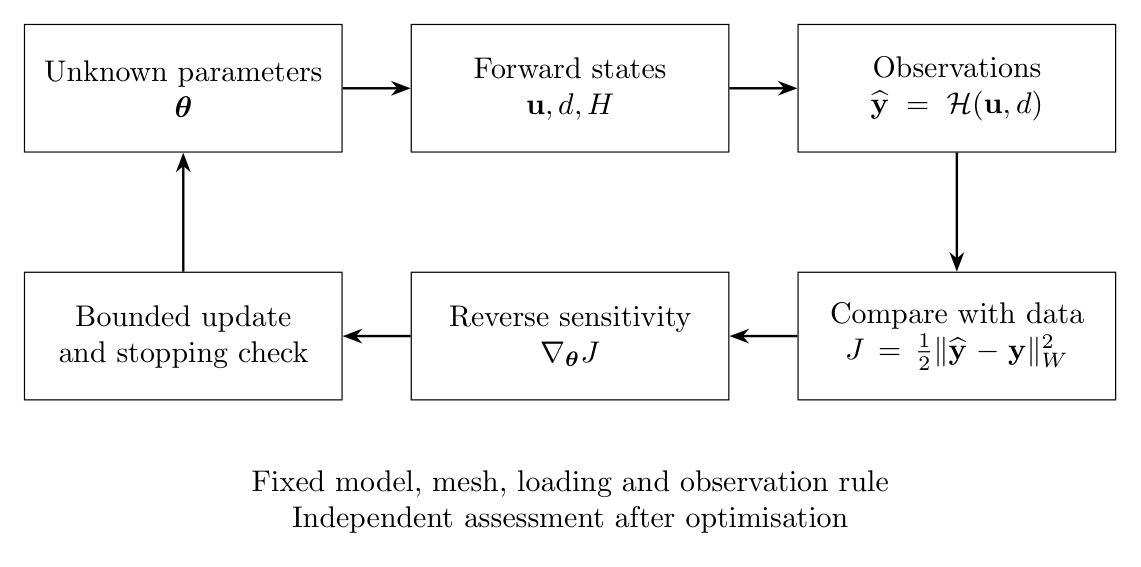

In [1]:
import time
notebook_started = time.perf_counter()
import platform
from io import BytesIO
import numpy as np
import torch
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from IPython.display import Image, display

torch.set_default_dtype(torch.float64)
torch.set_num_threads(2)
plt.rcParams.update({
    "font.family": "STIXGeneral", "mathtext.fontset": "stix",
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "legend.fontsize": 10, "figure.dpi": 130,
})
BLUE, ORANGE, GREEN = "#0072B2", "#D55E00", "#009E73"
results, checks = {}, {}
d = results

def save(fig, name):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=180, bbox_inches="tight", pad_inches=.12)
    display(Image(data=buffer.getvalue(), alt=name.replace("_", " ")))
    plt.close(fig)

print({"python": platform.python_version(), "torch": torch.__version__,
       "numpy": np.__version__, "matplotlib": matplotlib.__version__,
       "device": "CPU", "dtype": str(torch.get_default_dtype())})

{'python': '3.11.15', 'torch': '2.8.0+cu128', 'numpy': '2.4.2', 'matplotlib': '3.10.8', 'device': 'CPU', 'dtype': 'torch.float64'}


# Representing particles and testing their geometry

## The unknowns

Consider a circular stiff particle with centre $\mathbf c=(c_x,c_y)$ and
radius $r$. Its geometry is described by three numbers. For three particles,
the parameter vector has nine entries:

$$\boldsymbol\theta=(c_{x,1},c_{y,1},r_1,c_{x,2},c_{y,2},r_2,c_{x,3},c_{y,3},r_3).$$

Coordinates and radii have units of length. Material contrasts, loading,
boundary conditions, mesh and observation times are prescribed in a geometry
recovery. If any of these are also unknown, they must be added to the problem
statement and sensitivity analysis.

## Moving a material field on a fixed mesh

A sharp indicator switches from zero to one at the particle boundary. When
that boundary passes a mesh point, the nodal material assignment jumps. A
smooth indicator offers a different parameterisation:

$$s(\mathbf x;\mathbf c,r)=\frac{1}{1+\exp[(\|\mathbf x-\mathbf c\|-r)/\varepsilon]}.$$

The transition width $\varepsilon$ has units of length. At distance $r$,
$s=1/2$. One possible stiffness field is

$$E(\mathbf x)=E_0[1+(\kappa_E-1)s(\mathbf x)],$$

where $\kappa_E>1$ describes a stiff particle. The physical mesh stays fixed;
the material values change as the centre moves. This differs from remeshing a
sharp geometric boundary. The transition width is part of the model and must
be reported.

Let $q=\|\mathbf x-\mathbf c\|$. Differentiating the sigmoid gives
$\partial s/\partial r=s(1-s)/\varepsilon$ and, for $q>0$,
$\nabla_{\mathbf c}s=s(1-s)(\mathbf x-\mathbf c)/(\varepsilon q)$.
These formulas explain where geometric sensitivity comes from. It is
concentrated near the transition, where $s(1-s)$ is largest. A material
derivative still has to pass through equilibrium and the observation loss
before it becomes a useful inverse-update direction.

The sigmoid smooths the interface. The Euclidean norm still has a directional
ambiguity exactly at the centre. A code that regularises that distance must
document its formula and test the centre separately.

In [2]:
def geometry():
    distances = torch.linspace(0, 7, 281, requires_grad=True)
    energy = torch.relu(4-distances).square()/2
    derivative = torch.autograd.grad(energy.sum(), distances)[0]
    p = torch.zeros((2, 2), requires_grad=True)
    radius = torch.tensor([2., 2.])
    penalty = torch.relu(radius.sum()-torch.linalg.vector_norm(p[0]-p[1])).square()/2
    g = torch.autograd.grad(penalty, p)[0]
    x = np.linspace(-5, 5, 401)
    epsilon = [.15, .4, 1.]
    indicators = [1/(1+np.exp((np.abs(x)-2)/eps)) for eps in epsilon]
    return {'distance': distances.detach().tolist(), 'energy': energy.detach().tolist(),
            'derivative': derivative.tolist(), 'coincident_gradient': g.tolist(),
            'x': x.tolist(), 'epsilon': epsilon, 'indicators': [a.tolist() for a in indicators]}, {
            'overlap_gradient_finite': bool(torch.isfinite(g).all()),
            'coincident_centres_have_zero_separating_gradient': bool((g==0).all()),
            'separated_energy_zero': float(energy[-1].detach()) == 0,
            'tangent_energy_zero': float(torch.relu(torch.tensor(4.)-4)**2)==0}

results['geometry'], outcomes = geometry()
checks.update({key: bool(value) for key, value in outcomes.items()})
print(outcomes)
assert all(outcomes.values())

{'overlap_gradient_finite': True, 'coincident_centres_have_zero_separating_gradient': True, 'separated_energy_zero': True, 'tangent_energy_zero': True}


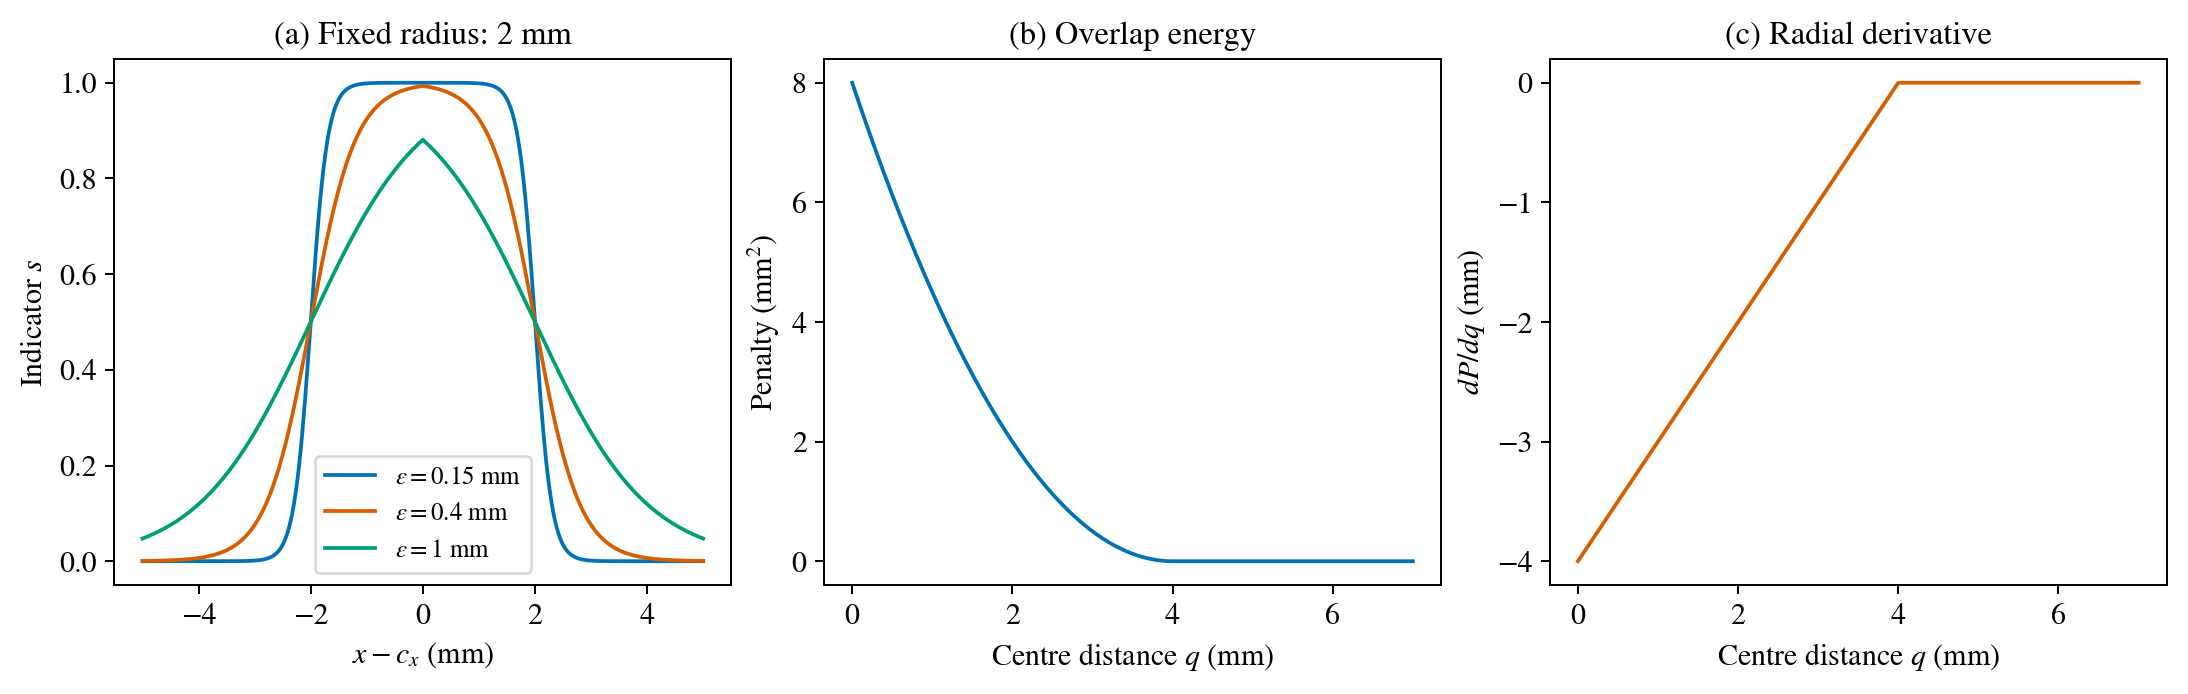

In [3]:
g=d['geometry']
fig,ax=plt.subplots(1,3,figsize=(12,3.7),layout='constrained')
for eps,y,c in zip(g['epsilon'],g['indicators'],[BLUE,ORANGE,GREEN]):ax[0].plot(g['x'],y,color=c,label=f'$\\varepsilon={eps:g}$ mm')
ax[0].set(xlabel='$x-c_x$ (mm)',ylabel='Indicator $s$',title='(a) Fixed radius: 2 mm')
ax[0].legend()
ax[1].plot(g['distance'],g['energy'],color=BLUE)
ax[1].set(xlabel='Centre distance $q$ (mm)',ylabel='Penalty (mm$^2$)',title='(b) Overlap energy')
ax[2].plot(g['distance'],g['derivative'],color=ORANGE)
ax[2].set(xlabel='Centre distance $q$ (mm)',ylabel='$dP/dq$ (mm)',title='(c) Radial derivative')
save(fig,'geometry')

Original teaching calculations: smooth indicators across a circular particle,
overlap energy and its radial derivative. The material curves are analytic,
not simulated crack fields.

For several particles, a bounded union is
$s_{\mathrm{union}}=1-\prod_i(1-s_i)$. Overlapping transition regions need
an explicit material-mixture rule; adding indicators can exceed one.

## Separation does not identify the particles

An overlap penalty discourages two circles from occupying the same region.
For two equal-radius particles, let $q=\|\mathbf c_1-\mathbf c_2\|$. A
simple teaching energy is

$$P(q)=\frac12[\max(0,2r-q)]^2.$$

For $0<q<2r$, $P'(q)=q-2r$. At $q>2r$, the energy and gradient are zero.
The penalty enforces geometric plausibility; it supplies no measurement of
the true particle positions.

At coincident centres, the Euclidean distance has no unique direction of
increase. An autodiff library can return a finite zero subgradient. Thus
the code can be numerically finite while providing no separating direction.
A declared, target-independent perturbation of duplicate initial centres is
one possible remedy. Changing the penalty is another modelling choice that
needs its own test.

## Exercise 1: predict the transition

(a) What is $s$ at the centre, at the stated radius and far outside it?
(b) Sketch what happens when $\varepsilon$ doubles.
(c) Explain why changing $\varepsilon$ merely to obtain a nicer crack picture
would change the inverse problem.

### Worked solution

At the centre the value is $1/(1+e^{-r/\varepsilon})$, close to one when
$r/\varepsilon$ is large. At the radius it is exactly one half; far outside
it approaches zero. Doubling the width broadens the transition and changes
the spatial stiffness distribution. The forward response and sensitivities
therefore change, even though the nominal centre and radius stay fixed.

## Exercise 2: interpret the coincidence test

The retained check finds a finite zero gradient for two coincident centres.
Does this establish that the overlap problem is solved? Propose a test with
a very small, prescribed separation and compare the direction of the update.

### Worked solution

No. The overlap energy is positive. The zero vector supplies no direction in
which to move. A small separation removes the directional ambiguity and the
negative gradient moves the centres apart. This is a geometry test; it gives
no evidence that a fracture observation can localise either particle.

## Exercise 3: a geometry checklist

Check positive radii, admissible centres, minimum separation, field bounds,
permutation invariance and finite gradients. Check the complete circles,
not only their centres, against the specimen boundary.

### Worked checklist

For a rectangular plate, require each centre to remain at least its radius
from every edge. Swapping particle labels should leave the union unchanged.
Test finite derivatives at the centre, near the interface and outside the
particle. An overlap check is separate from the measurement residual.

The [ADL4P sphere-packing exercise](https://github.com/tum-pbs/ADL4P/blob/main/exercises/ADL4P%20EX%203%20-%20Sphere%20Packing.pdf)
motivates this diagnostic. Our plate is nonperiodic; a circle leaving one
edge does not re-enter at the opposite edge.

# From measurements to a loss

## Separate the state from the measurement

The solver computes displacement $\mathbf u$, damage $d$ and history
variables. A camera or displacement sensor observes a function of this state.
Write $\widehat{\mathbf y}=\mathcal H(\mathbf u,d)$, where $\mathcal H$
is the observation operator, and define the residual
$\mathbf r=\widehat{\mathbf y}-\mathbf y^{\mathrm{obs}}$.

For nodal synthetic damage, $\mathcal H$ simply selects the required nodes
and times. For a registered displacement measurement at point $\mathbf x_p$
inside a triangle, use the shape functions:

$$\widehat{\mathbf u}_p=\sum_{a=1}^{3}N_a(\mathbf x_p)\mathbf u_a.$$

The containing element and interpolation weights belong to the observation
setup. Points outside the specimen and invalid measurements require masks.
A segmented crack image is not automatically a measured nodal damage field.
Its comparison requires a declared image/phase-field observation model.

For a triangle with vertices $(0,0),(1,0),(0,1)$, the shape functions are
$N_1=1-x-y$, $N_2=x$, $N_3=y$. A measurement at $(0.25,0.25)$ therefore
uses weights $(0.5,0.25,0.25)$. If one displacement component at the vertices
is $(0,2,4)$, its predicted value at that measurement is $1.5$ in the same
displacement units. The weights sum to one and reproduce a constant field.
On a general triangle, solve for the barycentric weights using its vertex
coordinates. Register camera pixels to physical specimen coordinates first.

## Nodal averages and spatial integrals

The nodal mean square is $J_{\mathrm{node}}=N^{-1}\sum_i r_i^2$.
An area-normalised field error is

$$J_{\mathrm{area}}=\frac{1}{|\Omega|}\int_\Omega r_h(\mathbf x)^2\,d\Omega.$$

These have the same units but different spatial weighting. Adding nodes to
one part of the plate changes its contribution to the nodal mean. A spatial
integral weights physical area.

For linear interpolation on a triangle of area $A_e$, the consistent mass
matrix is

$$M_e=\frac{A_e}{12}\begin{bmatrix}2&1&1\\1&2&1\\1&1&2\end{bmatrix},
\qquad \int_{\Omega_e}r_h^2\,d\Omega=\mathbf r_e^T M_e\mathbf r_e.$$

A lumped approximation assigns $A_e/3$ to each vertex. It is convenient,
but it is not the same integral of the squared linear interpolant.

In [4]:
def quadrature():
    records=[]
    for name,x in [('uniform',np.linspace(0,1,41)),('left_refined',np.r_[np.linspace(0,.25,31),np.linspace(.25,1,11)[1:]])]:
        h=np.diff(x)
        lump=np.zeros_like(x)
        lump[:-1]+=h/2
        lump[1:]+=h/2
        consistent=float(np.sum(h*(x[:-1]**2+x[:-1]*x[1:]+x[1:]**2)/3))
        records.append({'name':name,'x':x.tolist(),'residual':x.tolist(),
                        'nodal_mse':float(np.mean(x*x)), 'lumped_mse':float(np.dot(lump,x*x)),
                        'consistent_mse':consistent,'exact_integral':1/3})
    return records, {'consistent_integral_exact_on_both_meshes':all(abs(r['consistent_mse']-1/3)<1e-14 for r in records),
                     'nodal_average_changes_with_sampling':abs(records[0]['nodal_mse']-records[1]['nodal_mse'])>.05}

results['quadrature'], outcomes = quadrature()
checks.update({key: bool(value) for key, value in outcomes.items()})
print(outcomes)
assert all(outcomes.values())

{'consistent_integral_exact_on_both_meshes': True, 'nodal_average_changes_with_sampling': True}


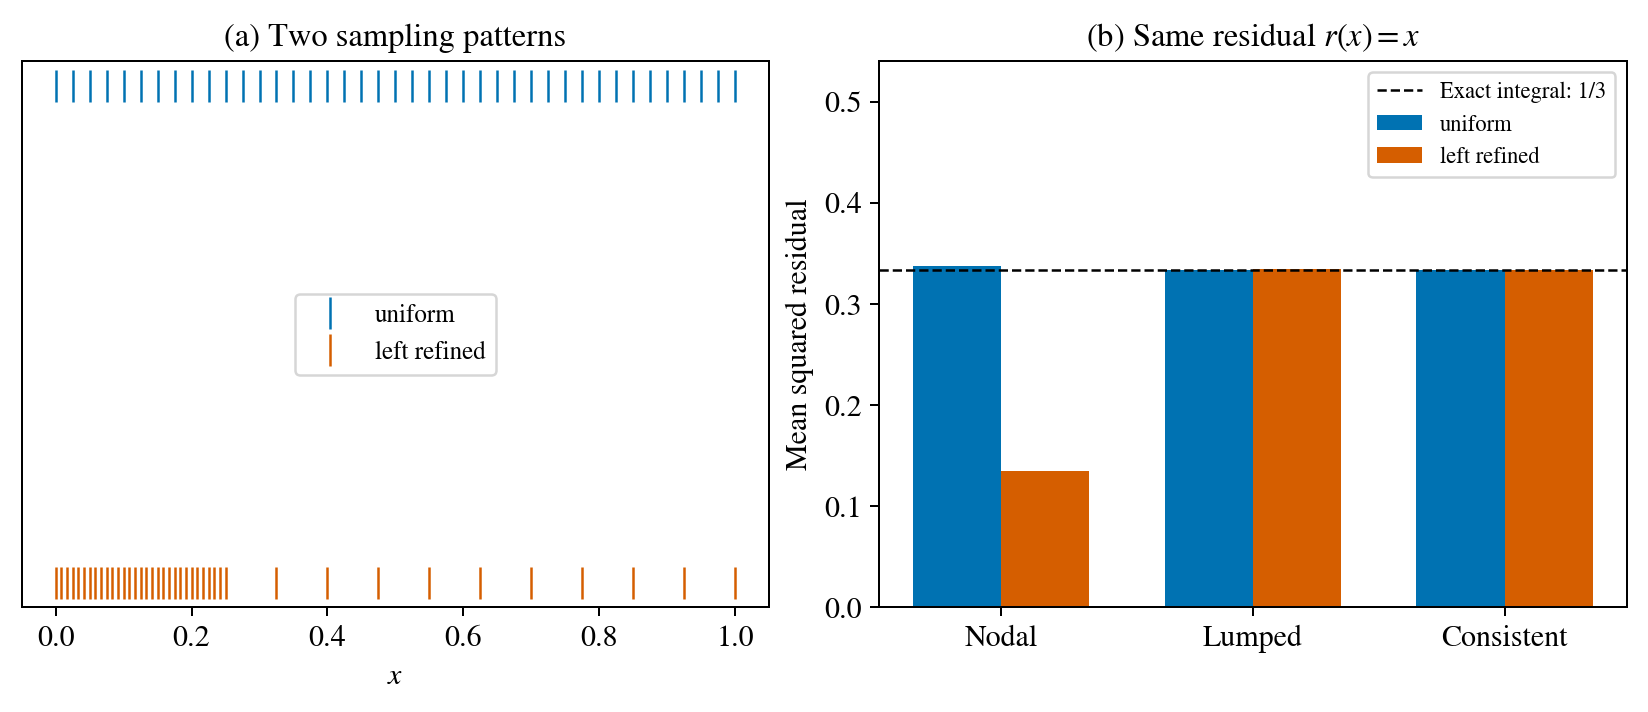

In [5]:
q=d['quadrature']
fig,ax=plt.subplots(1,2,figsize=(9,3.8),layout='constrained')
for r,y,c in zip(q,[1,0],[BLUE,ORANGE]):ax[0].plot(r['x'],np.full(len(r['x']),y),'|',ms=13,color=c,label=r['name'].replace('_',' '))
ax[0].set(xlabel='$x$',yticks=[],title='(a) Two sampling patterns')
ax[0].legend(loc='center')
x=np.arange(3)
for i,r in enumerate(q):ax[1].bar(x+(i-.5)*.35,[r['nodal_mse'],r['lumped_mse'],r['consistent_mse']],width=.35,label=r['name'].replace('_',' '),color=[BLUE,ORANGE][i])
ax[1].axhline(1/3,color='black',ls='--',lw=1,label='Exact integral: 1/3')
ax[1].set(xticks=x,xticklabels=['Nodal','Lumped','Consistent'],ylim=(0,.54),ylabel='Mean squared residual',title='(b) Same residual $r(x)=x$')
ax[1].legend(fontsize=9,loc='upper right')
save(fig,'quadrature')

The same residual $r(x)=x$ sampled on two one-dimensional meshes. The exact
integral is $1/3$. Refining the left region changes the nodal average; the
consistent finite-element integral remains exact for this example.

Neither choice is universally preferable. Equally reliable independent
nodal measurements can justify equal measurement weights. A continuum field
norm asks a different question. State the intended measure before selecting
the formula.

## Combining displacement and damage

Damage is dimensionless; displacement has units of length. Adding their raw
squares makes the objective depend on the displacement unit. One option is

$$J=\alpha_d\frac{\|d-d^{\mathrm{obs}}\|_W^2}{s_d^2}
+\alpha_u\frac{\|\mathbf u-\mathbf u^{\mathrm{obs}}\|_W^2}{s_u^2}.$$

Here $s_d$ and $s_u$ are declared scales; $W$ contains observation or spatial
weights. Noise-based weighting is appropriate when a defensible noise model
is available. A dimensionless objective can still have unbalanced parameter
gradients. Inspect both term values and $\nabla_\theta J_d$,
$\nabla_\theta J_u$.

Keep fitting data separate from final assessment data. Define normalisation
using the fitting set or fixed physical scales, so the final assessment does
not influence the optimisation through preprocessing.

## Exercise 1: calculate the mesh effect

Take $r(x)=x$ on $[0,1]$. Compute $\int_0^1r^2dx$. Predict whether adding
many samples near $x=0$ increases or decreases the nodal mean.

### Worked solution

The integral is $[x^3/3]_0^1=1/3$. Additional samples near zero decrease the
unweighted mean because more small residuals receive equal weight. The
underlying residual field has not improved.

## Exercise 2: choose the right claim

A retained recovered field has a smaller area-weighted error than its nodal
error. Has a new, better inverse recovery been obtained?

### Worked solution

The recovered field is unchanged. We have evaluated it with a different
measure. A new optimisation would be needed to study whether minimising that
measure produces a different recovery. Preserve both results and their
definitions.

## Exercise 3: units and assessment

Convert displacement from metres to millimetres. How should $s_u$ change?
Why should it not be estimated from final-assessment observations?

### Worked solution

Multiply both the residual and $s_u$ by 1000; their ratio is unchanged.
Using final-assessment observations to set the scale makes them influence
the fitting objective. The separation between fitting and assessment is
then weaker than the description suggests.

## Handling uncertain measurements

For a scalar displacement residual $r_p$, a robust alternative is the Huber
penalty

$$\rho_\delta(r)=
\begin{cases}r^2/2,&|r|\leq\delta,\\
\delta(|r|-\delta/2),&|r|>\delta.
\end{cases}$$

Use $\sum_p m_p w_p\rho_\delta(r_p)/\sum_p m_p w_p$, with nonnegative
confidence weights $w_p$ and validity masks $m_p$. A positive denominator
is required. The derivative equals $r$ inside the quadratic region and
$\delta\,\mathrm{sign}(r)$ outside it: large residuals have bounded
influence, rather than being automatically discarded. For displacement
vectors, state whether the penalty acts on components or on the vector norm.
This is an observation-model option; the executed quadrature example uses
the squared residual and makes no noise-robustness claim.

# Verify a derivative before interpreting an update

## A two-degree-of-freedom example

Consider the nondimensional linear equilibrium problem

$$A(\theta)\mathbf u=\mathbf b,\quad
A(\theta)=\begin{bmatrix}e^\theta+1&-1\\-1&2\end{bmatrix},\quad
\mathbf b=\begin{bmatrix}1\\0.2\end{bmatrix}.$$

The positive coefficient $e^\theta$ plays the role of a stiffness. We observe
both displacement components and define
$J=\frac12\|\mathbf u-(0.2,0.3)^T\|^2$. The matrix is symmetric positive
definite, so this small system has a unique equilibrium state. This statement
concerns the forward system; it is not a general statement about inverse
uniqueness.

## Central finite differences

At fixed $\theta$, evaluate $J(\theta+h)$ and $J(\theta-h)$:

$$D_hJ=\frac{J(\theta+h)-J(\theta-h)}{2h}.$$

This is a derivative with respect to **log stiffness**. Perturbing stiffness
itself instead would calculate a different coordinate derivative. For $m$
unknowns, a full coordinate-wise central-FD gradient requires $2m$ perturbed
forwards; a separate baseline evaluation adds one more.

## The adjoint calculation

Differentiate the equilibrium equation:
$A\,d\mathbf u=d\mathbf b-(dA)\mathbf u$. Define the adjoint through
$A^T\boldsymbol\lambda=\mathbf u-\mathbf y^{\mathrm{obs}}$. Then

$$\frac{dJ}{d\theta}=\boldsymbol\lambda^T
\left(\frac{d\mathbf b}{d\theta}-\frac{dA}{d\theta}\mathbf u\right)
=-\lambda_1 e^\theta u_1.$$

The derivative of the operator matters. Differentiating only the load vector
would give the wrong result in this example. We solve the adjoint equation;
we do not explicitly form $A^{-1}$.

PyTorch's differentiable linear solve supplies the same derivative through
automatic differentiation. The retained calculation compares that value with
the hand-derived adjoint and an FD step-size sweep.

The reported discrepancy is
$|D_hJ-g_{\mathrm{AD}}|/\max(|D_hJ|,|g_{\mathrm{AD}}|,10^{-30})$.
Both derivatives use the same logarithmic coordinate.

In [6]:
def solve_loss(theta):
    A=torch.stack([torch.stack([theta.exp()+1.,theta.new_tensor(-1.)]),torch.stack([theta.new_tensor(-1.),theta.new_tensor(2.)])])
    b=theta.new_tensor([1.,.2])
    u=torch.linalg.solve(A,b)
    y=theta.new_tensor([.2,.3])
    return .5*((u-y)**2).sum(), A, u, y

def derivatives():
    theta=torch.tensor(.3,requires_grad=True)
    loss,A,u,y=solve_loss(theta)
    ad=torch.autograd.grad(loss,theta)[0]
    adjoint=torch.linalg.solve(A.detach().T,(u-y).detach())
    implicit=-adjoint[0]*theta.detach().exp()*u.detach()[0]
    hs=np.logspace(-1,-9,17)
    fds=[]
    for h in hs:
        with torch.no_grad():
            fds.append(float((solve_loss(theta+h)[0]-solve_loss(theta-h)[0])/(2*h)))
    relative=[abs(x-float(ad))/max(abs(x),abs(float(ad)),1e-30) for x in fds]
    return {'theta':float(theta.detach()),'ad':float(ad),'implicit':float(implicit), 'h':hs.tolist(),'fd':fds,'relative_error':relative}, {
        'ad_matches_implicit':bool(torch.allclose(ad,implicit,rtol=1e-12,atol=1e-14)),
        'fd_has_accurate_intermediate_steps':min(relative)<1e-7}

results['derivatives'], outcomes = derivatives()
checks.update({key: bool(value) for key, value in outcomes.items()})
print(outcomes)
assert all(outcomes.values())

{'ad_matches_implicit': True, 'fd_has_accurate_intermediate_steps': True}


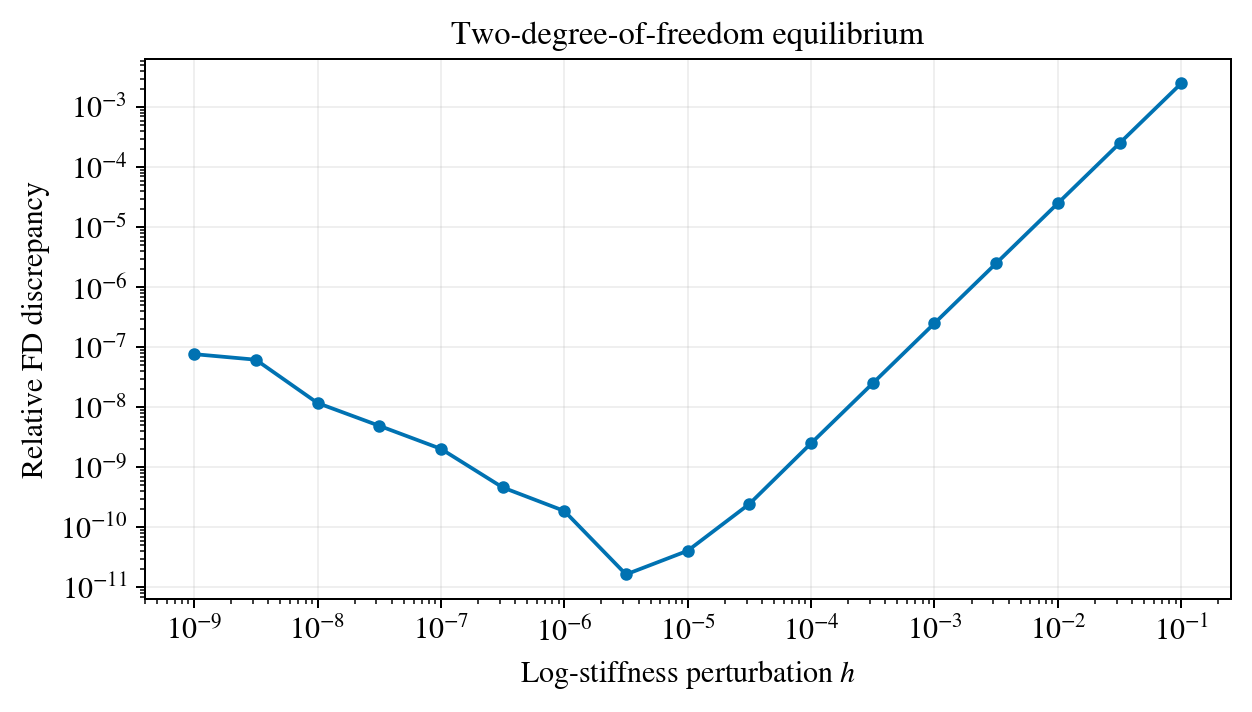

In [7]:
v=d['derivatives']
fig,ax=plt.subplots(figsize=(6.8,3.8),layout='constrained')
ax.loglog(v['h'],np.maximum(v['relative_error'],1e-16),'o-',color=BLUE,ms=4)
ax.set(xlabel='Log-stiffness perturbation $h$',ylabel='Relative FD discrepancy',title='Two-degree-of-freedom equilibrium')
ax.grid(alpha=.2,which='major')
save(fig,'derivatives')

Relative central-FD discrepancy against AD for the small equilibrium model.
The hand-derived adjoint provides a second comparison. Individual values
come from the retained computation; the line connects sampled step sizes.

## Time-dependent fracture adds history

A complete time-step state can be written as
$\mathbf z_n=(\mathbf u_n,\mathbf v_n,d_n,H_n,\ldots)$.
For fixed time steps, let $\mathbf z_{n+1}=F_n(\mathbf z_n,\theta)$.
Reverse differentiation accumulates contributions from every operation in
which $\theta$ appears. A parameter used at every step contributes more
than its effect on the final step alone.

Damage bounds and updates such as $H_{n+1}=\max(H_n,\psi^+_{n+1})$
introduce branch choices. The selected branch can have a useful derivative
even when a finite perturbation selects another branch. Record branch
information and examine the step-size dependence before attributing a
disagreement to either AD or FD.

## Unrolling and the reverse recurrence

Suppose the objective includes several observation times:
$J=\sum_{n=0}^{N}\ell_n(\mathbf z_n,\theta)$.
Define $\boldsymbol\lambda_n$ as the derivative of the remaining objective
with respect to the state at step $n$. The reverse calculation starts at
$\boldsymbol\lambda_N=\partial_{\mathbf z_N}\ell_N$ and proceeds through

$$\boldsymbol\lambda_n=\partial_{\mathbf z_n}\ell_n+
(\partial_{\mathbf z_n}F_n)^T\boldsymbol\lambda_{n+1}.$$

The complete parameter derivative is

$$\frac{dJ}{d\theta}
=\sum_{n=0}^{N}\partial_\theta\ell_n
+\sum_{n=0}^{N-1}(\partial_\theta F_n)^T\boldsymbol\lambda_{n+1}
+(\partial_\theta\mathbf z_0)^T\boldsymbol\lambda_0.$$

The last term matters when initial conditions depend on the unknown
parameters. It vanishes for prescribed parameter-independent initial states.
Each partial derivative holds its other arguments fixed. Reverse AD evaluates
these vector--Jacobian products through the recorded operations without
building every full Jacobian matrix.

An implicit derivative of an inner equilibrium solve and an unrolled
time-history derivative can therefore occur in the same programme. The former
handles one solve; the latter carries its influence through subsequent states.
Neither computes a global loss landscape.

## Exercise 1: the missing operator term

Set $d\mathbf b/d\theta=0$. Explain why the sensitivity is generally still
nonzero, and identify the exact matrix entry responsible in this example.

### Worked solution

The load is fixed but the stiffness changes. Only $A_{11}$ depends on
$\theta$, with derivative $e^\theta$. The displacement changes through
equilibrium, giving $-\lambda_1e^\theta u_1$.

## Exercise 2: a reliable comparison

What must remain identical in the AD and FD forward evaluations? Why should
we retain the larger-step discrepancies as well as the best agreement?

### Worked solution

Use the same mesh, loading, objective, parameter coordinate, history reset,
time steps, constraints and numerical tolerances. Only the prescribed
parameter perturbation changes. The full sweep shows finite-step behaviour;
selecting only the best point conceals that information.

## Exercise 3: count the work

For nine unknowns, how many perturbed forwards does a central-FD coordinate
gradient require? Does an AD update cost only one forward calculation?

### Worked solution

Central FD requires 18 perturbed forwards. Reverse AD needs a recorded
forward plus reverse work. Rejected line-search trials and diagnostics are
additional calculations and should be counted. Fewer forwards is not itself
a wall-time speedup measurement.

## Exercise 4: differentiate two steps

Take $z_0=1$, $z_{n+1}=\theta z_n$ for two steps and
$J=\tfrac12(z_2-y)^2$. Compare the complete derivative with a calculation
that mistakenly holds $z_1$ fixed.

### Worked solution

Since $z_2=\theta^2$, the complete derivative is
$2\theta(\theta^2-y)$. Holding $z_1$ fixed keeps only the second step's
direct contribution, $\theta(\theta^2-y)$. The missing contribution travels
through $z_1$. This simple example explains why detaching intermediate states
changes the differentiated map.

# Differentiating fracture: memory, switches and useful limits

## What is the derivative of a simulation?

Suppose we change a particle centre or a fracture-energy parameter by a small
amount. We ask how the **predicted observations and their mismatch** change.
For parameters $\theta$, states $z$, an observation operator $\mathcal O$ and
measured data $y$, the chain is

$$\theta\longmapsto z_0,z_1,\ldots,z_N
\longmapsto\mathcal O(z)\longmapsto J(\theta).$$

Differentiability is a local property of this map with respect to specified
inputs. It is different from continuity of a field in space. Every operation
on the relevant parameter-to-loss path needs an appropriate derivative rule.
Fixed mesh connectivity, logging and parameter-independent preprocessing do
not themselves need derivatives. A custom implicit backward rule can cover
an entire numerical solve without recording every inner iteration.

Start with one spring: $ku=f$, $J=\frac12(u-y)^2$. Its derivative is
$dJ/dk=-(u-y)u/k$. If $\theta=\log k$, the chain rule gives
$dJ/d\theta=k\,dJ/dk$. The same principle applies to a finite-element solver;
the difficult part is preserving every dependence and identifying switches.

## Three different meanings of smoothness

**Spatial regularisation.** A sharp crack has a displacement jump. Phase-field
fracture represents damage with a spatial field $d\in[0,1]$ and a length scale
$\ell_0$. For example, $d(x)=\exp(-|x|/\ell_0)$ is an illustrative diffuse
profile normal to a crack, not a newly computed PhAST solution. Increasing
$\ell_0$ changes the represented damage width and the model. It does not
automatically smooth the parameter-to-observation map.

**A kink in an update.** $\max(a,b)$ is continuous: approaching a tie does
not produce a jump in its value. Its slope changes abruptly. A step function
is a different object, with a discontinuous value. Damage bounds, positive
energy splits and history maxima introduce such nonsmooth choices even on a
fixed mesh with a spatially diffuse crack.

**A change of solution branch.** Crack initiation, competing paths and
instabilities can cause a parameter perturbation to follow a different
evolution. The local derivative of the current numerical trajectory does
not predict every alternative trajectory.

Some teaching fluid solvers have fixed grids, smooth operators and modest
time horizons, which makes differentiation easier to demonstrate. Fluid
mechanics also includes shocks, interfaces, flux limiters, changing contacts
and chaotic long-time sensitivity. The useful comparison is between smooth,
well-conditioned discrete maps and nonsmooth or unstable maps, rather than
between fluids and solids as entire disciplines.

## Memory during loading and unloading

For the tensile-energy history formulation, each material sampling point
retains its largest crack-driving energy:

$$H_{n+1}=\max(H_n,\psi^+_{n+1}).$$

Here $\psi^+$ is the configured tensile driving energy density, not damage or
strain itself. On unloading the current energy can fall, while $H$ remembers
the earlier maximum. PhAST also applies damage bounds; the history field
alone should not be described as the complete bound-constrained algorithm.

Holding $H_n$ fixed, $\partial H_{n+1}/\partial\psi^+$ equals zero below
$H_n$ and one above it. At a tie there is generally no unique classical
partial derivative. PyTorch's elementwise maximum assigns half to each
operand at equality. This is a differentiation convention, not a proof of
smoothness. If both operands have identical parameter derivatives, their
composition can still be differentiable at a tie.

For a concrete unloading example, take $H_n(\theta)=2\theta$ and
$\psi^+_{n+1}(\theta)=\theta$ near $\theta=1$. The old history wins, but
$dH_{n+1}/d\theta=2$. Only the route through the **current energy** is
inactive; sensitivity through the stored history remains. Detaching that
history would remove a real contribution.

## What PhAST actually implements

The source provides several selectable history operators. A result must be
identified by its effective configuration, not merely by the presence of an
operator in the repository.

| History choice | Forward value | Reverse rule | Meaning |
|---|---|---|---|
| `hard_max` without a legacy smoothing override | $\max(a,b)$ | Active branch; half at a tie | Local hard-map derivative away from switches |
| `softmax` | $\beta^{-1}\log(e^{\beta a}+e^{\beta b})$ | Derivative of this smooth forward | Changes the history model |
| `custom_subgrad` | $\max(a,b)$ | Sigmoid-weighted rule | Surrogate reverse derivative near a switch |
| `custom_subgrad_dimensionless` in the research worktree | $\max(a,b)$ | Sigmoid of a scaled energy difference | Same distinction with explicit units |

The dispatcher also provides quadratic and log-domain smooth alternatives.
There is a legacy detail: selecting `hard_max` with a positive
`softmax_H_beta` invokes a softplus smooth maximum. Therefore both settings
must be recorded. These are available routes, not evidence that every
historical experiment used the same route.

### Smooth forward: bias is part of the choice

The operator called `softmax` in this code is a scalar **log-sum-exp smooth
maximum**. The usual softmax returns normalized weights; those weights are
the derivatives of log-sum-exp. With $a=H_n$ and $b=\psi^+$,

$$S_\beta(a,b)=\frac{1}{\beta}\log(e^{\beta a}+e^{\beta b}),
\qquad \partial_b S_\beta=\sigma[\beta(b-a)],
\qquad \sigma(q)=\frac{1}{1+e^{-q}}.$$

Numerically use `logsumexp`, `logaddexp` or stable softplus, rather than
forming potentially overflowing exponentials. Its one-update bias satisfies
$0\le S_\beta-\max(a,b)\le\log(2)/\beta$. At equality this is
$\log(2)/\beta$. Repeatedly updating against a constant energy $c$, starting
from $H_0=c$, gives $H_n=c+\log(n+1)/\beta$. Artificial history growth can
therefore occur without increased loading. A small local bias is not a
guarantee of negligible trajectory error.

### Hard forward with a custom reverse rule

The custom implementation saves the two operands and a scalar sharpness.
It returns the exact hard maximum. Given an incoming loss sensitivity
$\overline H=\partial J/\partial H_{n+1}$, it returns

$$\overline a=\overline H\,\sigma[s(a-b)],\qquad
\overline b=\overline H\,\sigma[s(b-a)].$$

It saves neither a full Jacobian matrix nor a history of strain Jacobians.
These products are the local vector--Jacobian product (VJP). Later backward
steps carry $\overline a$ through the earlier history. Away from a tie, a
finite-width sigmoid differs from the classical derivative of the hard
forward. It is a **surrogate gradient**, even when it helps optimisation.
Differentiating the smooth sibling validates the sigmoid formula; it does
not validate that formula as an exact derivative of the hard forward.

For example, set $a=1$, $b=0.99$, $s=10$. Small perturbations of $b$ keep the
hard output at 1, so the hard-map FD derivative is zero. The custom reverse
rule gives $\sigma(-0.1)\simeq0.475$. Both numbers describe their respective
rules correctly. The difference is retained in the computation below.

The research variant uses $s=\widehat s/\psi_{\rm ref}$, so the sigmoid
argument $\widehat s(a-b)/\psi_{\rm ref}$ is dimensionless. The scale
$\psi_{\rm ref}$ is a fixed positive reference energy in this rule; its
derivative is not included. Converting energy units requires converting that
reference too. Very sharp sigmoids can saturate to zero or one in finite
precision, so a nonzero gradient on both branches is not guaranteed.

In [8]:
def history_rules():
    import numpy as np
    import torch

    class HardForwardSigmoidBackward(torch.autograd.Function):
        @staticmethod
        def forward(ctx, a, b, scale):
            ctx.save_for_backward(a, b)
            ctx.scale = scale
            return torch.maximum(a, b)

        @staticmethod
        def backward(ctx, upstream):
            a, b = ctx.saved_tensors
            return (upstream * torch.sigmoid(ctx.scale * (a-b)),
                    upstream * torch.sigmoid(ctx.scale * (b-a)), None)

    def custom(a, b, scale=10.0):
        return HardForwardSigmoidBackward.apply(a, b, scale)

    x = torch.linspace(.6, 1.4, 401, dtype=torch.float64, requires_grad=True)
    a = torch.ones_like(x)
    hard = torch.maximum(a, x)
    smooth = torch.logaddexp(10*a, 10*x) / 10
    proxy = custom(a, x)
    gh = torch.autograd.grad(hard.sum(), x, retain_graph=True)[0]
    gs = torch.autograd.grad(smooth.sum(), x, retain_graph=True)[0]
    gp = torch.autograd.grad(proxy.sum(), x)[0]
    tie_a = torch.tensor(1., dtype=torch.float64, requires_grad=True)
    tie_b = torch.tensor(1., dtype=torch.float64, requires_grad=True)
    ties = torch.autograd.grad(torch.maximum(tie_a, tie_b), (tie_a, tie_b))
    theta = torch.tensor(1., dtype=torch.float64, requires_grad=True)
    old_route = torch.autograd.grad(torch.maximum(2*theta, theta), theta)[0]
    b = torch.tensor(.99, dtype=torch.float64, requires_grad=True)
    one = torch.ones_like(b)
    surrogate = torch.autograd.grad(custom(one, b), b)[0].item()
    eps = 1e-6
    hard_fd = (max(1., .99+eps)-max(1., .99-eps))/(2*eps)
    smooth_fd = (np.logaddexp(10., 10*(.99+eps))-
                 np.logaddexp(10., 10*(.99-eps)))/(20*eps)
    values = [.2, .8, .4, 1.2, .7]
    routes = {}
    for label in ('hard', 'surrogate'):
        energies = torch.tensor(values, dtype=torch.float64, requires_grad=True)
        hist = torch.zeros((), dtype=torch.float64)
        for energy in energies:
            hist = torch.maximum(hist, energy) if label == 'hard' else custom(hist, energy, 4.)
        routes[label] = torch.autograd.grad(hist, energies)[0].tolist()
    repeated = [1.]
    for _ in range(40):
        repeated.append(float(np.logaddexp(10*repeated[-1], 10.)/10))
    expected = 1 + np.log(np.arange(41)+1)/10
    reference = .006
    energy_gap = .001
    weight = torch.sigmoid(torch.tensor(6*energy_gap/reference)).item()
    converted_weight = torch.sigmoid(torch.tensor(6*(energy_gap*1e6)/(reference*1e6))).item()
    saturated = torch.sigmoid(torch.tensor(-1e3, dtype=torch.float64)).item()
    checks = {
        'history_custom_forward_exact': torch.equal(hard, proxy),
        'history_hard_tie_halves': all(t.item() == .5 for t in ties),
        'history_old_route_retained': old_route.item() == 2.,
        'history_hard_losing_branch_zero': hard_fd == 0.,
        'history_surrogate_mismatch_preserved': abs(surrogate-hard_fd) > .4,
        'history_smooth_sibling_fd': abs(surrogate-smooth_fd) < 1e-8,
        'history_smooth_bias_bound': bool(torch.all(smooth-hard <= np.log(2)/10+1e-14)),
        'history_repeat_bias_formula': bool(np.allclose(repeated, expected, rtol=0, atol=1e-14)),
        'history_exact_peak_route': routes['hard'] == [0., 0., 0., 1., 0.],
        'history_unit_invariance': abs(weight-converted_weight) < 1e-14,
        'history_sigmoid_saturation_retained': saturated == 0.,
    }
    result = {
        'x': x.detach().tolist(), 'hard': hard.detach().tolist(),
        'smooth': smooth.detach().tolist(), 'hard_gradient': gh.tolist(),
        'smooth_gradient': gs.tolist(), 'surrogate_gradient': gp.tolist(),
        'energies': values, 'routes': routes, 'repeat_smooth': repeated,
        'hard_fd': hard_fd, 'surrogate': surrogate, 'smooth_fd': smooth_fd,
        'scope': 'dimensionless history primitives; not a fracture recovery',
    }
    return result, {k: bool(v) for k, v in checks.items()}

results['history_rules'], outcomes = history_rules()
checks.update({key: bool(value) for key, value in outcomes.items()})
print(outcomes)
assert all(outcomes.values())

{'history_custom_forward_exact': True, 'history_hard_tie_halves': True, 'history_old_route_retained': True, 'history_hard_losing_branch_zero': True, 'history_surrogate_mismatch_preserved': True, 'history_smooth_sibling_fd': True, 'history_smooth_bias_bound': True, 'history_repeat_bias_formula': True, 'history_exact_peak_route': True, 'history_unit_invariance': True, 'history_sigmoid_saturation_retained': True}


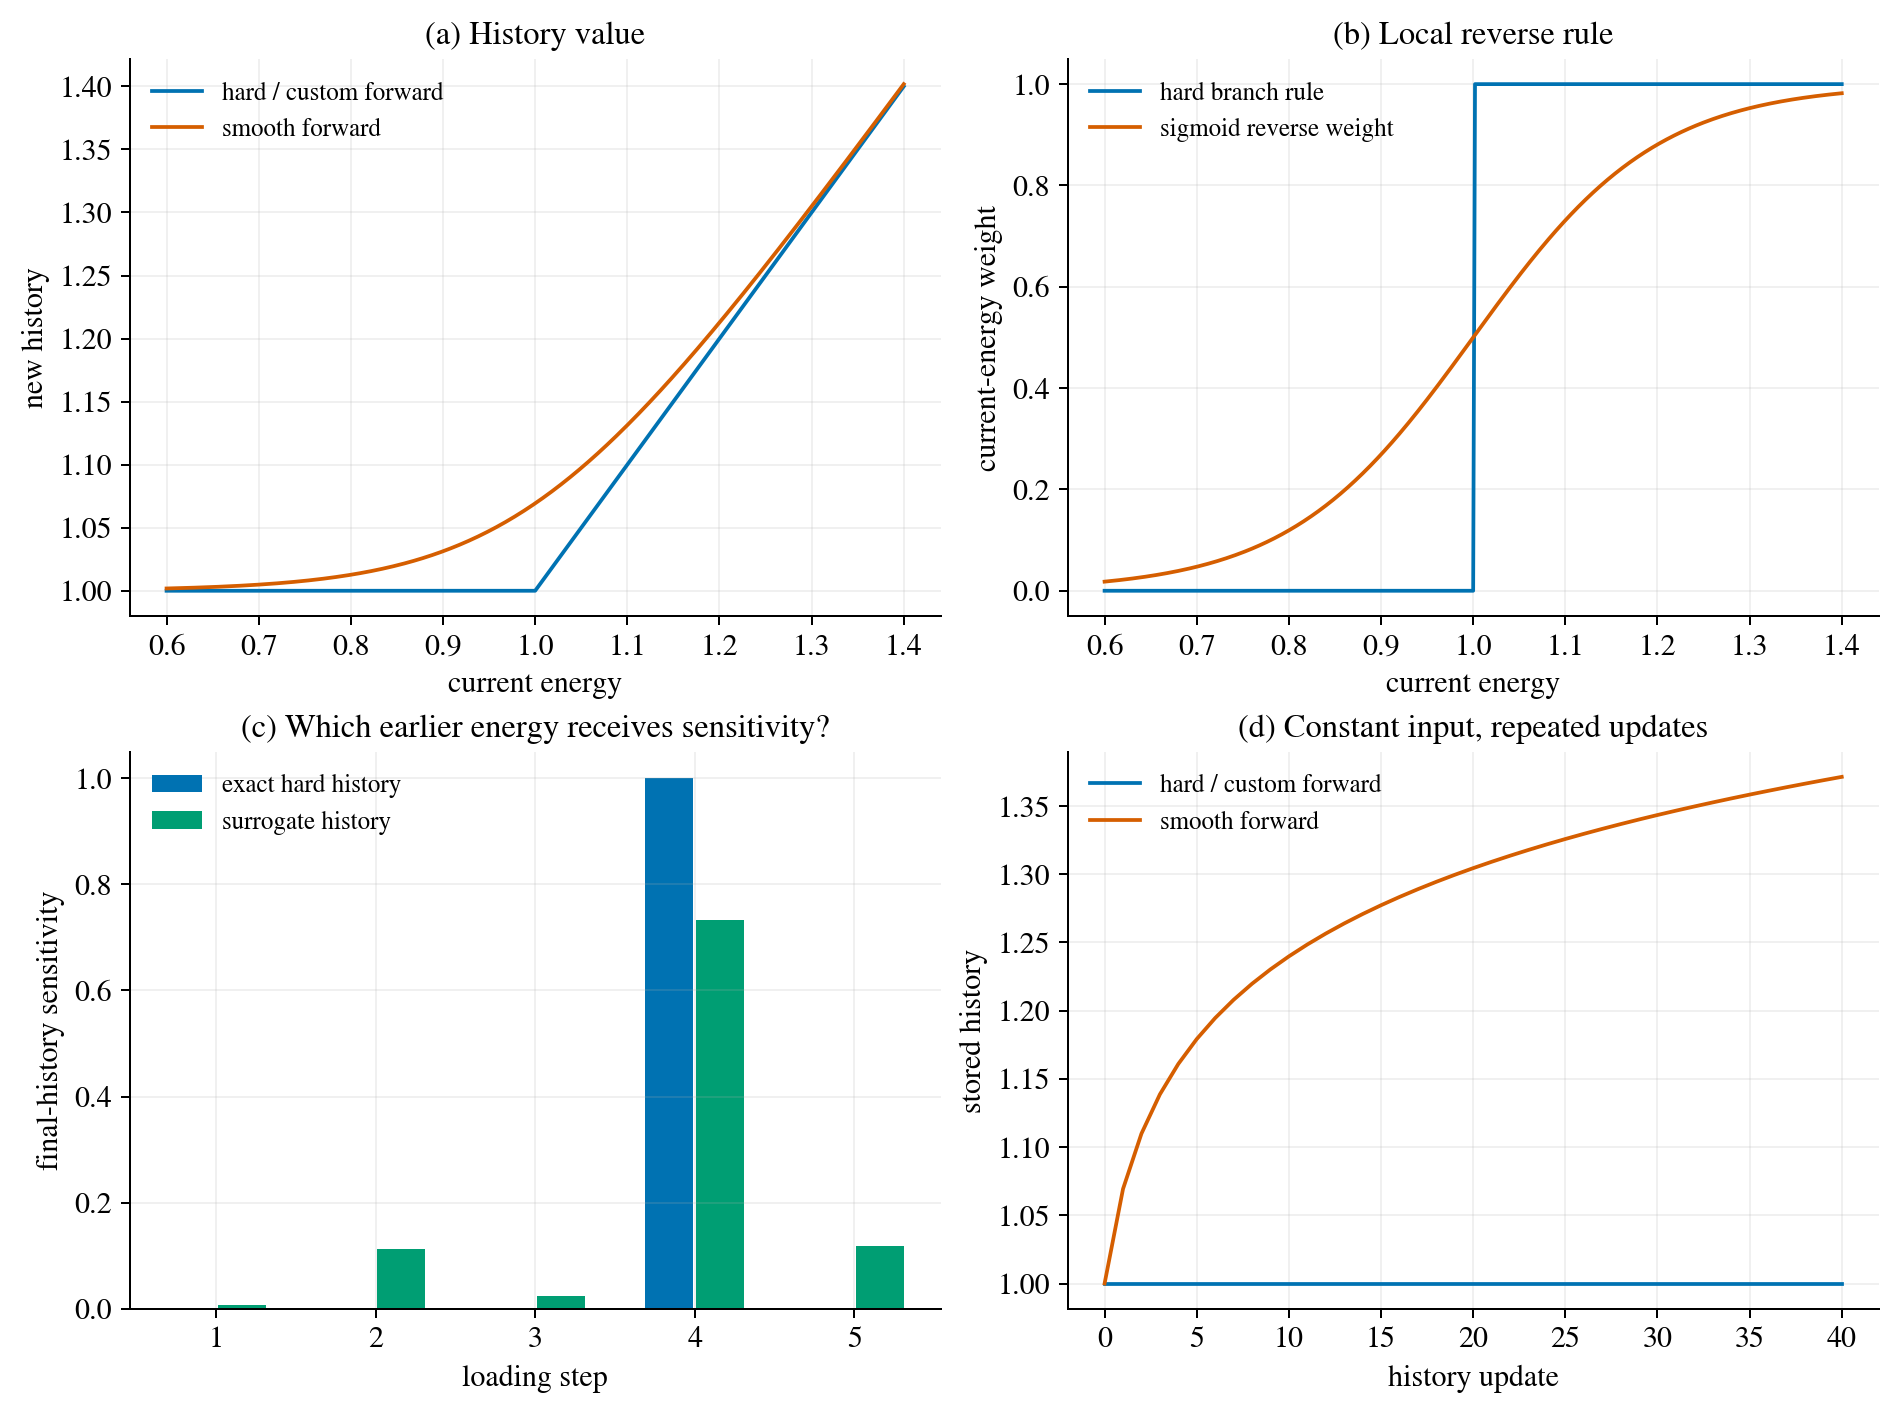

In [9]:
def plot_history_rules(result):
    import matplotlib.pyplot as plt
    import numpy as np
    fig, axes = plt.subplots(2, 2, figsize=(10.4, 7.7), layout='constrained')
    blue, orange, green = '#0072B2', '#D55E00', '#009E73'
    ax = axes[0, 0]
    ax.plot(result['x'], result['hard'], color=blue, label='hard / custom forward')
    ax.plot(result['x'], result['smooth'], color=orange, label='smooth forward')
    ax.set(title='(a) History value', xlabel='current energy', ylabel='new history')
    ax.legend(loc='upper left', frameon=False)
    ax = axes[0, 1]
    ax.plot(result['x'], result['hard_gradient'], color=blue, label='hard branch rule')
    ax.plot(result['x'], result['surrogate_gradient'], color=orange,
            label='sigmoid reverse weight')
    ax.set(title='(b) Local reverse rule', xlabel='current energy', ylabel='current-energy weight')
    ax.legend(loc='upper left', frameon=False)
    ax = axes[1, 0]
    steps = np.arange(1, 6)
    ax.bar(steps-.16, result['routes']['hard'], width=.3, color=blue, label='exact hard history')
    ax.bar(steps+.16, result['routes']['surrogate'], width=.3, color=green, label='surrogate history')
    ax.set(title='(c) Which earlier energy receives sensitivity?',
           xlabel='loading step', ylabel='final-history sensitivity', xticks=steps)
    ax.legend(loc='upper left', frameon=False)
    ax = axes[1, 1]
    ax.plot(np.arange(41), np.ones(41), color=blue, label='hard / custom forward')
    ax.plot(np.arange(41), result['repeat_smooth'], color=orange, label='smooth forward')
    ax.set(title='(d) Constant input, repeated updates', xlabel='history update', ylabel='stored history')
    ax.legend(loc='upper left', frameon=False)
    for ax in axes.flat:
        ax.grid(alpha=.18)
        ax.spines[['top', 'right']].set_visible(False)
    return fig

save(plot_history_rules(results['history_rules']), 'history_rules')

Four views of the same distinction. (a) The custom rule shares the hard
forward; log-sum-exp changes its value. (b) The sigmoid is a smooth-forward
derivative or a hard-forward surrogate, depending on the forward choice.
(c) With distinct energy peaks, exact history sensitivity reaches the
largest earlier peak; a finite-width surrogate redistributes it. (d) Repeated
constant-energy updates reveal the smooth-forward bias. All quantities here
are dimensionless teaching examples, not fitted fracture results.

## How the derivative passes through a damage solve

For an illustrative interior AT2 subproblem with fixed boundary data,

$$R=A(H,G_c,\ell_0)\widetilde d-b(H,G_c,\ell_0)=0.$$

Implicit differentiation gives
$A\,d\widetilde d=db-(dA)\widetilde d$.
For a scalar objective, solving $A^T\lambda=\overline{\widetilde d}$ yields
$\overline q=\lambda^T(b_q-A_q\widetilde d)$ for each input $q$.
The operator derivative $A_q$ matters as much as the right-hand-side
derivative. This is an equation-level derivative evaluated with finite
solver accuracy, assuming a locally invertible reduced operator.

For a **solve-then-project** map
$d_{n+1}=\min(1,\max(d_n,\widetilde d))$, the strictly interior nodes route
sensitivity to $\widetilde d$. Strictly lower-active nodes route it to $d_n$;
strictly upper-active nodes route none to either when the bound 1 is fixed.
The adjoint right-hand side is masked accordingly. The operator derivative
uses the pre-projection $\widetilde d$, not the clipped field. A different
projected iterative or constrained-equilibrium forward requires its own
consistent backward derivation. We must establish which map was executed
before applying this formula. Requested tolerances should be accompanied by
measured residuals; an unattained request is not a tighter solved system.

The time loop then composes mechanics, energy, history and damage VJPs using
the preceding chapter's reverse recurrence. Checkpointing recomputes saved
segments to reduce memory; it must reproduce the same states and branches.
Higher-order derivatives need additional verification, especially through
custom backward routines implemented under `no_grad`.

## Where useful gradients end: a diagnostic guide

| Situation | What to inspect | Interpretation and a targeted response |
|---|---|---|
| Stable active branches, converged solves and a backward consistent with the executed forward | Directional FD sweep and primal/adjoint residuals | Local derivative agreement is expected; record coordinates and operating point |
| History tie, damage bound or energy-split switch | One-sided slopes, perturbation sizes, branch identities | A unique classical derivative can fail; report the selected convention or surrogate |
| Surrogate reverse rule near a switch | Hard-forward FD and smooth-sibling formula separately | Preserve disagreement; assess search usefulness separately from exactness |
| Excessive smoothing | History drift, crack onset and parameter estimates versus smoothing scale | Smooth-forward bias is a model effect; use stable, unit-consistent scales and retain comparisons |
| Gradient saturation or uninformative loading | Observation sensitivity and individual gradient routes | A correct zero derivative can be physical; consider richer observations/loading, not invented information |
| Nearly singular mechanics/damage operator | Measured residuals and conditioning | Implicit sensitivities can become large or unreliable; improve solves and diagnose the operating point |
| Different crack paths or failed forward convergence | Full fields, event times, stopping status | Local sensitivities need a stated branch and valid forward trajectory |
| Long trajectories or unstable time steps | Gradient norm versus horizon, stability and replay agreement | Products can vanish or amplify; checkpointing saves memory but does not cure instability |
| Broken dependency or stale solver state | Detached tensors, overwritten caches, reset history and immutable solve data | An implementation fault can silently change the differentiated map; use small regression tests |
| Non-identifiable parameters | Observation-Jacobian rank and alternate parameter fits | Correct derivatives do not establish uniqueness; add independent data or state the ambiguity |

Finite-difference tests must reset histories and keep mesh, time steps,
objective, loading, coordinates and bound treatment matched. For a normalized
direction $v$, compare $[J(\theta+hv)-J(\theta-hv)]/(2h)$ with $g^Tv$ over a
range of $h$. If active-set memberships were not saved, aggregate count
changes establish that some membership changed, but cannot locate it; equal
counts do not prove equal memberships. A Taylor remainder with quadratic
decay is evidence on a smooth, resolved interval, not across every branch.

These are operational checks, not a universal threshold for how far a
particle can be initialized from its target. Recovery depends on loading,
observability, parameterization, mesh and optimisation as well as derivatives.

## Exercise 1: does unloading remove the gradient?

For $H_n=2\theta$ and $\psi^+=\theta$ at $\theta=1$, calculate the total
derivative of the new history. What would detaching $H_n$ do?

### Worked solution

The new history is $2\theta$, with derivative 2. Detaching it discards this
route and returns zero locally, although the physical parameter affects the
earlier loading. A zero current-energy partial derivative is not the same
as a zero total parameter derivative.

## Exercise 2: is agreement at a tie enough?

Central FD of $\max(0,q)$ at $q=0$ is one half. Does that prove smoothness?

### Worked solution

No. The left slope is zero and the right slope is one. Central FD averages
the two. A matching software value at that point does not establish a
unique classical derivative.

## Exercise 3: which smoothing changes the fracture calculation?

Distinguish changing $\ell_0$, changing the history forward to log-sum-exp,
and changing only the history backward to sigmoid weights.

### Worked solution

Changing $\ell_0$ changes the phase-field model and characteristic spatial
width. Log-sum-exp changes the history values and can change damage evolution.
The custom backward preserves hard history values for a fixed parameter
trajectory but changes the inverse update direction; later optimizer
iterates can therefore differ. None guarantees successful recovery.

## Source map and optional perspectives

The implementation inspection covers `phast/physics/h_update.py`,
`phast/physics/h_update_custom_subgrad.py`, `StaggeredSolver._H_update`, and
the implicit functions in `phast/solvers/damage_solver.py`. The public teaching
snapshot contains the dimensional custom rule; the explicit dimensionless
variant is in the Particle Inverse research worktree. Its manuscript describes
that variant for the single-particle study. This distinction is not transferred
to unrelated runs without their configuration receipts.

The accompanying teaching code is a minimal, self-contained illustration of
the audited rules. It is not a replacement damage solver. The private source
audit records exact files and hashes separately from these portable lessons.

[PyTorch's autograd documentation](https://docs.pytorch.org/docs/2.14/notes/autograd.html#gradients-for-non-differentiable-functions)
describes derivative conventions for nonsmooth primitives.
[Physics-based Deep Learning](https://physicsbaseddeeplearning.org/diffphys.html)
explains composing numerical operators and computing transpose-Jacobian
products without storing full matrices.
[Felix Koehler's Machine Learning and Simulation repository](https://github.com/Ceyron/machine-learning-and-simulation/tree/main/english/adjoints_sensitivities_automatic_differentiation)
contains complementary explicit and implicit adjoint examples.
[ADL4P](https://tum-pbs.github.io/ADL4P/) provides the broader course context.
All derivations required for this lesson appear above.

# Why a correct gradient can give slow or ambiguous recovery

## The gradient is local information

For a small increment, $J(\theta+\Delta\theta)\approx
J(\theta)+\nabla J^T\Delta\theta$. A negative dot product predicts a
local decrease. It does not describe the entire loss landscape. A distant
initial particle can produce a different crack branch or have little influence
on the selected observations.

To isolate conditioning, consider $J(p_1,p_2)=\frac12(p_1^2+100p_2^2)$.
The curvature in the second direction is 100 times larger. A step small enough
to be stable in that direction can move slowly in the first direction.

The plotted updates are $p^{k+1}=p^k-\alpha P\nabla J(p^k)$, starting from
$(2,2)$. Plain descent uses $P=I$ and $\alpha=0.015$. Scaled descent uses
$P=\mathrm{diag}(1,0.01)$ and $\alpha=0.8$. The latter is the inverse
Hessian of this known quadratic, so both coordinates contract by $0.2$
per update. Plain descent contracts the first coordinate by $0.985$ and
multiplies the second by $-0.5$, explaining its slow progress and zigzag.
These choices isolate conditioning; they are not a general optimiser ranking.

In [10]:
def conditioning():
    matrix=np.diag([1.,100.])
    paths={}
    for name,preconditioner,step in [('gradient',np.eye(2),.015),('scaled',np.diag([1.,.01]),.8)]:
        p=np.array([2.,2.]); rows=[]
        for _ in range(81):
            rows.append([*p,.5*float(p@matrix@p)])
            p=p-step*preconditioner@matrix@p
        paths[name]=rows
    return paths, {'scaled_quadratic_objective_smaller':paths['scaled'][-1][2]<paths['gradient'][-1][2],
                   'both_quadratic_objectives_decrease':all(np.all(np.diff(np.array(r)[:,2])<=1e-12) for r in paths.values())}

def observations():
    # A two-variable linearized observation model, not an actual inclusion solver.
    truth=np.array([.7,1.1]); records={}
    for name,J in [('one_observation',np.array([[1.,1.]])),('two_observations',np.array([[1.,1.],[1.,-1.]]))]:
        y=J@truth
        paths=[]
        for start in ([0.,0.],[1.5,0.]):
            p=np.array(start); rows=[]
            for _ in range(51):
                residual=J@p-y
                rows.append([*p,.5*float(residual@residual)])
                p-=.2*J.T@residual
            paths.append(rows)
        covariance=np.linalg.inv(np.eye(2)+(J.T@J)/.1**2)
        mean=covariance@J.T@y/.1**2
        records[name]={'J':J.tolist(),'y':y.tolist(),'paths':paths,
                        'posterior_mean':mean.tolist(),'posterior_covariance':covariance.tolist(),
                        'singular_values':np.linalg.svd(J,compute_uv=False).tolist()}
    return {'truth':truth.tolist(),'models':records,'noise_std':.1,'prior_mean':[0.,0.],'prior_covariance':np.eye(2).tolist()}, {
        'one_observation_has_null_direction':bool(np.allclose(np.array([[1.,1.]])@np.array([1.,-1.]),0)),
        'two_observations_recover_both_unknowns':all(np.linalg.norm(np.array(p[-1][:2])-truth)<1e-9 for p in records['two_observations']['paths']),
        'additional_observation_reduces_posterior_determinant':np.linalg.det(records['two_observations']['posterior_covariance'])<np.linalg.det(records['one_observation']['posterior_covariance'])}

results['conditioning'], outcomes = conditioning()
checks.update({key: bool(value) for key, value in outcomes.items()})
print(outcomes)
assert all(outcomes.values())

results['observations'], outcomes = observations()
checks.update({key: bool(value) for key, value in outcomes.items()})
print(outcomes)
assert all(outcomes.values())

{'scaled_quadratic_objective_smaller': True, 'both_quadratic_objectives_decrease': True}
{'one_observation_has_null_direction': True, 'two_observations_recover_both_unknowns': True, 'additional_observation_reduces_posterior_determinant': np.True_}


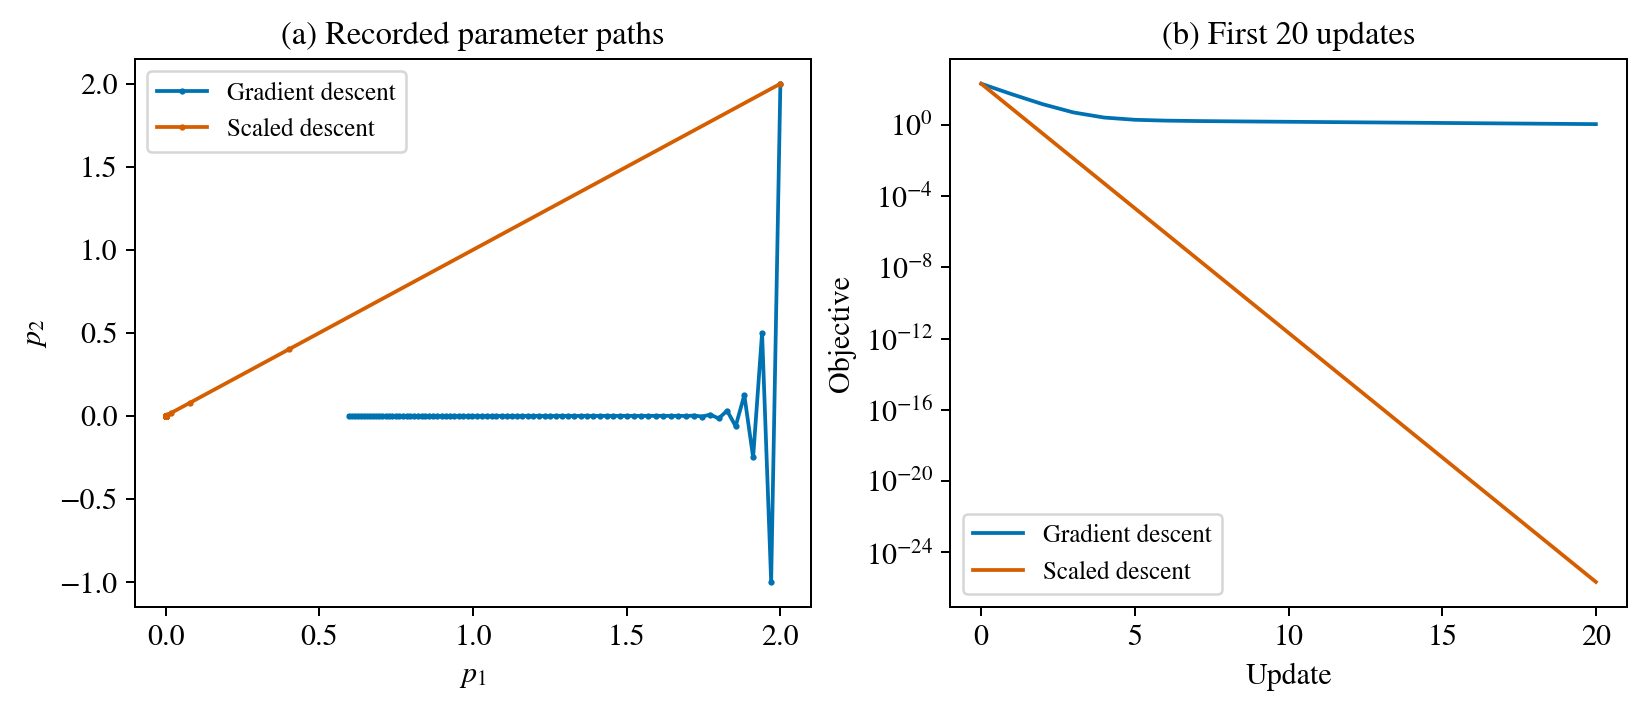

In [11]:
fig,ax=plt.subplots(1,2,figsize=(9,3.8),layout='constrained')
for name,c in [('gradient',BLUE),('scaled',ORANGE)]:
    p=np.array(d['conditioning'][name]);label={'gradient':'Gradient descent','scaled':'Scaled descent'}[name]
    ax[0].plot(p[:,0],p[:,1],'.-',ms=3,color=c,label=label)
    ax[1].semilogy(np.arange(21),p[:21,2],color=c,label=label)
ax[0].set(xlabel='$p_1$',ylabel='$p_2$',title='(a) Recorded parameter paths')
ax[1].set(xlabel='Update',ylabel='Objective',title='(b) First 20 updates')
ax[0].legend()
ax[1].legend()
save(fig,'conditioning')

Gradient descent and diagonally scaled descent on the same quadratic, using
the same initial state. The objective panel shows the first 20 updates;
the paths and retained data include 80 updates. Scaling is exact for this
teaching quadratic. The
figure does not establish a suitable preconditioner for fracture.

Normalising coordinates removes differences of units and admissible range.
It need not remove differences of sensitivity. A proposed sensitivity-based
scaling must also avoid magnifying numerically negligible gradient components.

## Two unknowns and one observation

Let two nondimensional perturbations be $p_1$ and $p_2$, and measure
$y_1=p_1+p_2$. They can be regarded as a local analogy for a position/radius
trade-off; they are not a full particle model. If $y_1=1.8$, every point on
$p_1+p_2=1.8$ matches that observation.

The Jacobian is $J_y=[1\;1]$. Moving along $(1,-1)^T$ changes neither the
observation nor its least-squares loss. This is a null direction. Starting at
different points can therefore lead to different parameter estimates with
equally small loss.

Add a second observation $y_2=p_1-p_2$. The combined Jacobian

$$J_y=\begin{bmatrix}1&1\\1&-1\end{bmatrix}$$

has two independent columns. The pair $y_1=1.8$, $y_2=-0.4$ determines
$p_1=0.7$, $p_2=1.1$ in this linear model.

We minimise $\tfrac12\|J_y p-y\|^2$ using
$p^{k+1}=p^k-0.2J_y^T(J_y p^k-y)$ for 50 updates, from $(0,0)$ and
$(1.5,0)$. The reference parameters are used to generate the synthetic
observations and to assess the estimates, never to select the updates.

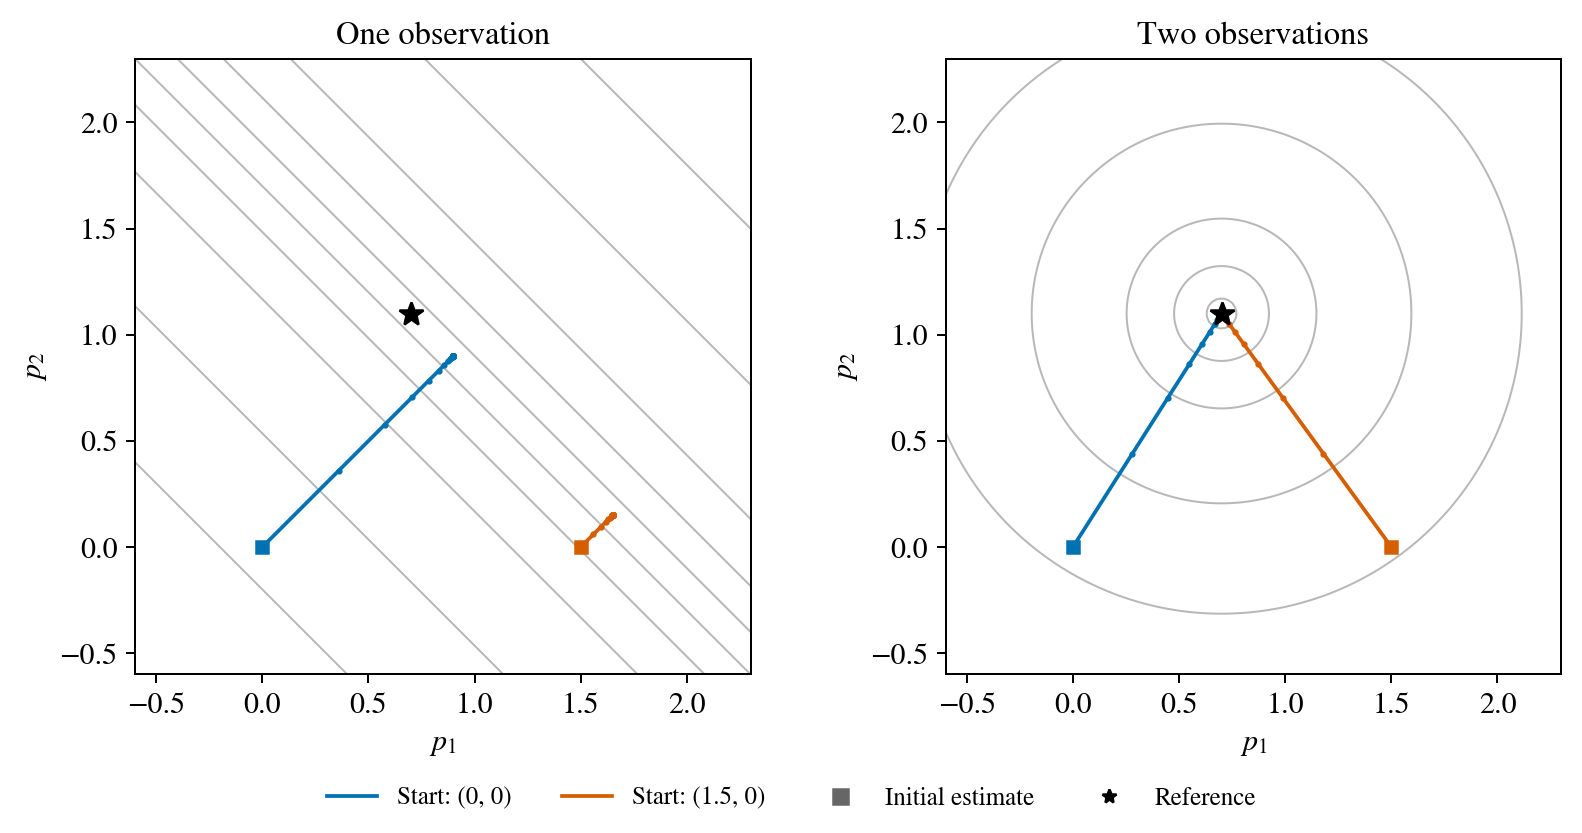

In [12]:
o=d['observations']
xx,yy=np.meshgrid(np.linspace(-.6,2.3,160),np.linspace(-.6,2.3,160))
fig,ax=plt.subplots(1,2,figsize=(9,4.5),layout='constrained')
for a,(name,r) in zip(ax,o['models'].items()):
    J=np.array(r['J']);target=np.array(r['y']);res=np.einsum('ij,jkl->ikl',J,np.array([xx,yy]))-target[:,None,None]
    levels=a.contour(xx,yy,.5*np.sum(res**2,axis=0),levels=[.005,.05,.2,.8,2],colors='.72',linewidths=.8)
    for path,c in zip(r['paths'],[BLUE,ORANGE]):
        p=np.array(path);a.plot(p[:,0],p[:,1],'.-',ms=3,color=c)
        a.plot(p[0,0],p[0,1],'s',color=c,ms=5)
    a.plot(*o['truth'],'*',ms=10,color='black');a.set(xlabel='$p_1$',ylabel='$p_2$',aspect='equal',title=name.replace('_',' ').capitalize())
fig.legend(handles=[Line2D([],[],color=BLUE,label='Start: (0, 0)'),
                    Line2D([],[],color=ORANGE,label='Start: (1.5, 0)'),
                    Line2D([],[],color='.4',marker='s',ls='',label='Initial estimate'),
                    Line2D([],[],color='black',marker='*',ls='',label='Reference')],
           loc='outside lower center',ncol=4,frameon=False)
save(fig,'observations')

Loss contours and recorded optimisation paths for one and two observations.
The flat valley disappears when the added observation resolves its null
direction. These are computed teaching landscapes, not measured fracture
landscapes.

## What singular values tell us

For $J_y=U\Sigma V^T$, the columns of $V$ describe parameter directions.
The corresponding singular values describe the magnitude of observation
change for a unit perturbation in those directions. Their interpretation
depends on parameter units and observation weighting. A small singular value
indicates a weak local direction, not a proof of global non-uniqueness.

In a fracture experiment, compare observation times and loading cases with
the same declared parameter coordinates. Repeated measurements of nearly
the same response can improve noise averaging without resolving a missing
parameter direction.

## From ambiguity to uncertainty

To quantify uncertainty, we need a probability model. In this teaching
example, assume independent Gaussian measurement noise with standard deviation
$\sigma=0.1$ and a Gaussian prior $p\sim\mathcal N(0,I)$. For the linear
observation matrix, the posterior is exactly Gaussian:

$$C=(I+J_y^TJ_y/\sigma^2)^{-1},\qquad
\mu=CJ_y^T\mathbf y/\sigma^2.$$

To derive this, Bayes' rule multiplies the prior density by the likelihood.
Their negative log densities, up to constants, are
$\tfrac12p^Tp$ and $\|J_y p-y\|^2/(2\sigma^2)$.
Expanding and completing the square gives
$\tfrac12(p-\mu)^TC^{-1}(p-\mu)$, which identifies the covariance and
mean above. For two parameters, the plotted ellipse is
$(p-\mu)^TC^{-1}(p-\mu)=5.991$, the 95% quantile of a chi-square
distribution with two degrees of freedom. Its axes follow the covariance
eigenvectors. Their lengths scale with the square roots of its eigenvalues.

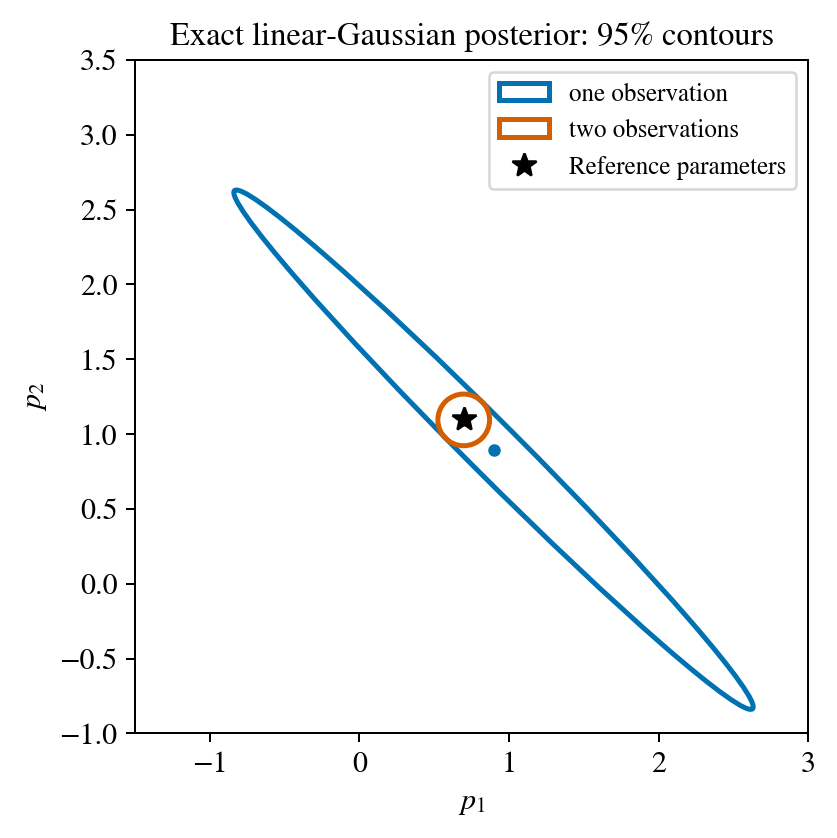

In [13]:
fig,ax=plt.subplots(figsize=(6.8,4.5),layout='constrained')
for (name,r),c in zip(o['models'].items(),[BLUE,ORANGE]):
    cov=np.array(r['posterior_covariance']);eig,V=np.linalg.eigh(cov);i=np.argmax(eig);angle=np.degrees(np.arctan2(V[1,i],V[0,i]))
    width,height=2*np.sqrt(5.991464547*np.array([eig[i],eig[1-i]]))
    ax.add_patch(Ellipse(r['posterior_mean'],width,height,angle=angle,fill=False,color=c,lw=2,label=name.replace('_',' ')))
    ax.plot(*r['posterior_mean'],'o',color=c,ms=4)
ax.plot(*o['truth'],'*',color='black',ms=10,label='Reference parameters')
ax.set(xlim=(-1.5,3),ylim=(-1,3.5),aspect='equal',xlabel='$p_1$',ylabel='$p_2$',title='Exact linear-Gaussian posterior: 95% contours')
ax.legend(loc='upper right')
save(fig,'uncertainty')

Posterior contours containing 95% probability for the declared two-dimensional
Gaussian model. The first observation leaves a broad trade-off direction.
The second constrains it. Filled circles denote posterior means and the star
marks the reference. With one observation, the prior selects a mean along
the trade-off direction. With two observations, it shifts the mean slightly
from the noise-free reference parameters.

This is the exact conditional distribution for the specified linear Gaussian
model. Its derivation does not test whether that noise model fits an experiment.
A cloud of successful fracture optimisations is not
automatically a posterior sample. Nonlinear fracture inference requires its
own priors, noise model and validation.

## Exercise 1: distinguish two difficulties

Compare the narrow quadratic valley with the one-observation example. Which
has a unique minimiser? Which has an unobserved parameter direction?

### Worked solution

The positive-definite quadratic has a unique minimiser but unequal curvature.
The one-observation objective has an entire line of minimisers. Scaling can
help the first problem; it cannot create the missing observation in the second.

## Exercise 2: choose an additional observation

Would $y_2=2p_1+2p_2$ resolve the null direction of $y_1=p_1+p_2$?

### Worked solution

No. Its sensitivity is parallel to the first row. Independent noise can
make repeated measurements useful, but this added row does not increase the
rank. An observation sensitive to $p_1-p_2$ is needed here.

## Exercise 3: interpret a far-start failure

A fracture run passes local AD--FD checks but finishes with one particle far
from its reference position. List two hypotheses and one diagnostic for each.

### Worked solution

Weak observability can be investigated with weighted Jacobian columns and
singular vectors. A restricted attraction basin can be investigated with
predeclared initial offsets and verified loss slices. Neither hypothesis
follows from the failed recovery alone. Keep the same physical model when
comparing these explanations.

# A useful role for learning: propose, solve and check

## Predicting a state and solving an equation

A learned prediction $\widetilde{\mathbf u}$ approximates a state. For a
linear equilibrium equation $A\mathbf u=\mathbf b$, evaluate its residual
$\mathbf r=\mathbf b-A\widetilde{\mathbf u}$. A visually plausible
prediction can still have a substantial residual.

One conservative use of a predictor is to provide an initial guess to the
original numerical solver. The solver continues until its declared residual
criterion is met. This retains a meaningful equation-based acceptance test.
It does not automatically establish physical accuracy of the underlying model.

## A learned linear initial guess

The teaching experiment uses a one-dimensional spring-like system with
24 unknowns. We construct two training load patterns and solve for their
displacements. A linear map fitted to those pairs predicts a displacement
for a third load containing an unseen component. Conjugate gradients then
corrects the prediction.

Let $n=24$, $x_i=i/(n+1)$ and
$A=\mathrm{tridiag}(-1,2.05,-1)$, with zero endpoint values.
The two columns of $B_{\mathrm{load}}$ are
$\sin(\pi x_i)$ and $\sin(2\pi x_i)$.
Solve $AU=B_{\mathrm{load}}$ and fit the minimum-norm linear map
$K=U B_{\mathrm{load}}^+$, where $+$ denotes the Moore--Penrose
pseudoinverse. It learns only the supplied load subspace. For
$b_i=\sin(\pi x_i)+0.2\sin(3\pi x_i)$, the prediction is $Kb$.
All quantities in this teaching system are nondimensional.

Conjugate gradients (CG) then solves the positive-definite system.
From $u_0$, form $r_0=b-Au_0$ and $p_0=r_0$. At each step,

$$\alpha_k=\frac{r_k^Tr_k}{p_k^TAp_k},\quad
u_{k+1}=u_k+\alpha_kp_k,\quad r_{k+1}=r_k-\alpha_kAp_k,$$

$$\beta_k=\frac{r_{k+1}^Tr_{k+1}}{r_k^Tr_k},\qquad
p_{k+1}=r_{k+1}+\beta_kp_k.$$

We recompute the displayed residual $\|b-Au_k\|/\|b\|$ and stop below
$10^{-11}$, with a cap of 48 iterations. The two comparisons use $u_0=0$
and $u_0=Kb$. In exact arithmetic, this constructed load excites only two
eigenmodes; the prediction removes the first, leaving one for correction.
This explains the exceptionally small iteration counts.

In [14]:
def hybrid():
    # Learn a reduced-basis initial guess; enforce the exact fixed linear system.
    n=24
    A=2*np.eye(n)-np.eye(n,k=1)-np.eye(n,k=-1)
    A+=.05*np.eye(n)
    x=np.arange(1,n+1)/(n+1)
    train=np.array([np.sin(np.pi*x), np.sin(2*np.pi*x)]).T
    targets=np.linalg.solve(A,train)
    B=targets@np.linalg.pinv(train)
    b=np.sin(np.pi*x)+.2*np.sin(3*np.pi*x)
    reference=np.linalg.solve(A,b)
    def cg(initial):
        u=initial.copy(); r=b-A@u; p=r.copy(); rows=[float(np.linalg.norm(r)/np.linalg.norm(b))]
        for _ in range(n*2):
            if rows[-1]<1e-11:break
            Ap=A@p; rr=r@r; alpha=rr/(p@Ap)
            u+=alpha*p; rnew=r-alpha*Ap
            p=rnew+(rnew@rnew)/rr*p; r=rnew
            rows.append(float(np.linalg.norm(b-A@u)/np.linalg.norm(b)))
        return u,rows
    zero,rz=cg(np.zeros(n)); warm,rw=cg(B@b)
    return {'x':x.tolist(),'prediction':(B@b).tolist(),'reference':reference.tolist(),'corrected':warm.tolist(),
            'zero_residuals':rz,'warm_residuals':rw,'scope':'Learned linear initial guess on a fixed 1D system; no wall-time speedup claim'}, {
        'corrected_solution_matches_direct_solve':bool(np.allclose(warm,reference,atol=1e-9)),
        'zero_start_also_matches_direct_solve':bool(np.allclose(zero,reference,atol=1e-9))}

results['hybrid'], outcomes = hybrid()
checks.update({key: bool(value) for key, value in outcomes.items()})
print(outcomes)
assert all(outcomes.values())

{'corrected_solution_matches_direct_solve': True, 'zero_start_also_matches_direct_solve': True}


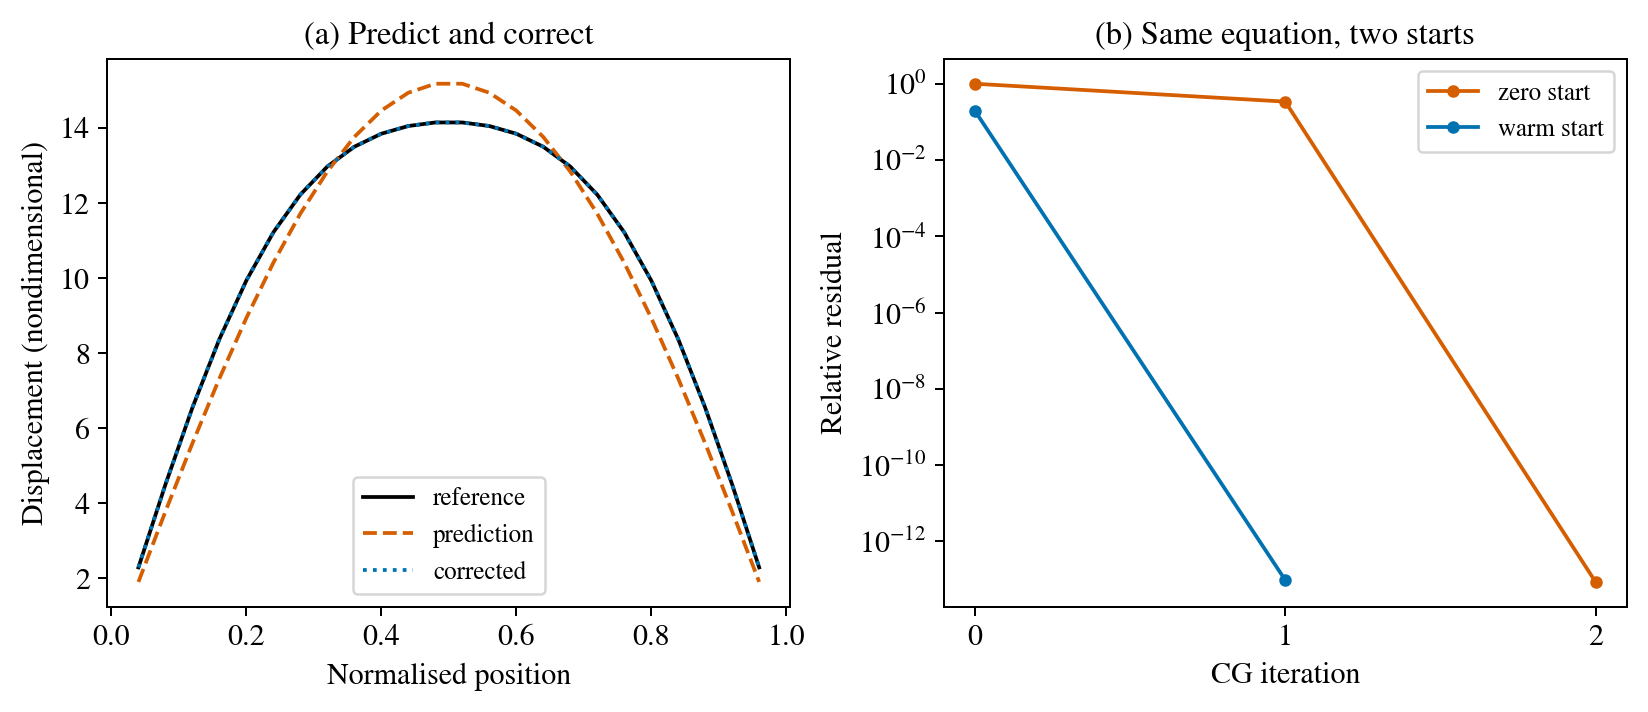

In [15]:
h=d['hybrid']
fig,ax=plt.subplots(1,2,figsize=(9,3.8),layout='constrained')
for name,c,style in [('reference','black','-'),('prediction',ORANGE,'--'),('corrected',BLUE,':')]:ax[0].plot(h['x'],h[name],color=c,ls=style,label=name)
for key,c in [('zero_residuals',ORANGE),('warm_residuals',BLUE)]:ax[1].semilogy(np.arange(len(h[key])),np.maximum(h[key],1e-16),'o-',color=c,label=key.split('_')[0]+' start',ms=4)
ax[0].set(xlabel='Normalised position',ylabel='Displacement (nondimensional)',title='(a) Predict and correct')
ax[1].set(xlabel='CG iteration',xticks=range(max(len(h['zero_residuals']),len(h['warm_residuals']))),ylabel='Relative residual',title='(b) Same equation, two starts')
ax[0].legend()
ax[1].legend()
save(fig,'hybrid')

The learned linear prediction, direct solution and corrected state, together
with residual histories. Fewer iterations in this small constructed example
is not a measured PhAST speedup. The zero initial guess is a necessary baseline.

The correction solves the same fixed positive-definite system as the direct
reference. At complete convergence, the initial guess does not change the
unique solution. With early termination, the initial guess influences the
returned state and potentially its derivative. State the stopping rule when
evaluating a learned solver component.

## Moving from a line to an unstructured mesh

A graph can represent finite-element connectivity. Nodes carry local state
and material features; edges carry relative coordinates and connectivity.
For fracture, plausible inputs include displacement, damage, history,
material coefficients and boundary masks.

A message-passing layer first computes messages between neighbours and then
aggregates them to update each node. An implementation must respect the actual
mesh: a geometric nearest-neighbour edge crossing a notch is not necessarily
a physical interaction. A graph network does not enforce equilibrium or
damage irreversibility simply because it uses a mesh.

For example, a layer can compute
$m_{ij}=f_\phi(h_i,h_j,x_j-x_i)$ and
$h_i'=g_\phi(h_i,\sum_{j\in\mathcal N(i)}m_{ij})$.
Here $h_i$ contains node features, $\mathcal N(i)$ contains its mesh
neighbours, and $f_\phi,g_\phi$ are trainable maps. Summation makes the
aggregation independent of neighbour ordering. Boundary conditions and
history still need explicit treatment. This formula explains the graph
extension; the executed predictor above is a fitted linear map, not a GNN.

## Three comparisons worth making

1. Prediction alone: how accurate is the state and its physical residual?
2. Prediction followed by the original solver: how much correction is needed?
3. Training through the solver: does differentiated feedback improve the
   closed-loop result relative to the same network and data without that feedback?

Measure preprocessing, graph construction, inference, correction, memory and
total time. Report matched residuals and field quality. A reduced iteration
count is useful evidence, but it does not include inference overhead.

## Exercise 1: diagnose the missing load component

The predictor was trained on the first two sine-shaped load patterns. Why
does a third-mode component require correction?

### Worked solution

The fitted linear map is constrained by the training subspace. The third
mode is independent of that subspace, so those examples do not determine its
response. The numerical solver evaluates the complete equation for the new load.

## Exercise 2: cost and fairness

A model reduces a solve from 20 to 10 iterations but adds expensive graph
construction. Which measurements establish acceleration?

### Worked solution

Measure matched end-to-end wall time, including construction and inference,
at the same residual and field-error criteria. Record warm-up separately and
repeat timings. The iteration reduction alone does not settle the comparison.

## Exercise 3: transfer to inverse recovery

Propose a learned initializer for particle centres and radii. What data split
would distinguish new-specimen generalisation from memorising one trajectory?

### Worked solution

Use observed fields to propose admissible parameters, then refine them with
PhAST. Split complete specimens or geometries between training and testing.
Randomly splitting snapshots of the same specimen shares its geometry across
the split and gives a weaker generalisation test.

See [ADL4P's GNN lecture](https://tum-pbs.github.io/ADL4P/slides/ADL4P%204%20-%20GNNs%20I.pdf)
and [solver-coupled learning lecture](https://tum-pbs.github.io/ADL4P/slides/ADL4P%203%20-%20Differentiable%20Physics%20II.pdf)
as optional further reading. The model, fitting rule, correction algorithm
and interpretation used in this lesson are specified above and in its code.

# Designing a fracture-inverse research programme

## Application 1: three particles ahead of a crack

We prescribe a notched plate, three stiff circular inclusions, material
contrasts and loading. The unknowns are the three centres and radii. The
observations are selected displacement and damage fields; synthetic damage
observations and experimental displacement measurements require different
observation contracts.

The first research question is precise: does increasing a prescribed initial
offset change recovery when everything else stays fixed? Use the same target,
mesh, material parameters, fitting observations, bounds, optimiser and budgets
at both initialisations. Keep particles inside the plate and preserve the
stated upper/lower grouping relative to the initial crack.

Compare four explicitly defined schedules:

| Schedule | Variables updated | Observations used |
|---|---|---|
| A: simultaneous | All nine | All fitting windows |
| B: strict sequential | One particle at a time; earlier estimates frozen | Current window and declared shared frames |
| C: cumulative | Expand from three to six to nine variables | Accumulate fitting windows |
| D: independent-window fusion | All nine independently per window | Separate windows, followed by a declared fusion rule |

All three particles remain in the forward model, even when only one is being
updated. Removing the other particles would change the physical problem.
Fusion weights must be defined from available observations and sensitivities;
selecting a rule using the true geometry would leak the synthetic answer.

Before interpreting the comparison, inspect forward convergence, initial
sensitivities, derivative checks, accepted updates, rejected trials and final
assessment fields. Matching update budgets does not match total forward work.

## Application 2: a distributed degraded stiffness field

For a diffuse weakened region, a useful parameterisation is
$E(\mathbf x)=E_0\,f(\sum_j a_j\phi_j(\mathbf x))$, where
$\phi_j$ are spatial basis functions and $f$ enforces a declared admissible
range. The coefficients $a_j$ replace individual circle parameters.

Basis centres locate functions; they are not independent physical particles.
Increasing their number increases representational freedom and can introduce
weakly observed combinations. Evaluate field error, observable error,
regularisation sensitivity and local parameter information separately.

For a barely visible impact damage motivation, explain the modelling link:
the recovered field represents a chosen stiffness-degradation model. A
synthetic weakened region is not itself an experimental impact-damage map.

## Application 3: selecting observations

Given several available fitting frames, examine which add independent
sensitivity directions. Begin with deterministic ranking and a measurement
budget. A new load case can be more informative than another similar time
frame, but it also requires a new forward experiment.

Reinforcement learning becomes relevant when sequential choices and their
future consequences justify training a policy. It should be compared with
a simpler information-based selection rule. Fracture history belongs to the
state; a damage image alone need not determine subsequent evolution.

## Application 4: uncertainty and generative proposals

If multiple material fields explain the data, a conditional model can propose
several candidates. Each candidate can be checked by PhAST. To interpret them
as a posterior distribution, specify priors, measurement noise and the
likelihood or inference approximation, then check calibration.

Diffusion and flow matching provide possible conditional models. They require
training data and introduce inference costs. Physics guidance can improve
residuals while changing the distribution of samples. Assess both physical
consistency and distributional quality.

## Exercise: a complete experiment card

Write a card for one of the applications. Include the following:

- Unknowns, units and admissible bounds.
- Fixed model, mesh, loading and initial state.
- Fitting observations, normalisation and independent assessment.
- Optimiser and stopping rule available without the true parameters.
- Forward and derivative checks, total work and resource budget.
- Stored fields, source fingerprint and the result needed to support the claim.

### Worked interpretation

For the three-particle application, stopping can use objective or step
criteria and a declared budget. True centre/radius errors are post-run
assessment quantities. A passing derivative check supports a local
sensitivity; geometric recovery and predictive agreement are separate
outcomes. Preserve failures and document exactly which assumptions differ
between experiments.

## Research status

The executable exercises in this extension are complete only when their
retained HPC checks pass. Full fracture comparisons, GNN training,
distributional inference and learned experiment design have separate issue
cards. A chapter explaining a proposed method does not mark that research
as completed.

# Inspect the results together

The following summary is calculated from this notebook's own execution.
The complete FD sweep and optimisation paths remain in `results`; the
figures do not replace those arrays. The checks include the deliberately
retained zero separating gradient at coincident centres.

In [16]:
assert len(checks) == 26 and all(checks.values()), checks
print(f"Checks passed: {sum(checks.values())} / {len(checks)}")
print(f"AD derivative: {results['derivatives']['ad']:.6g}")
print(f"Implicit derivative: {results['derivatives']['implicit']:.6g}")
print(f"Best sampled FD discrepancy: {min(results['derivatives']['relative_error']):.3g}")
truth = np.array(results["observations"]["truth"])
for i, path in enumerate(results["observations"]["models"]["two_observations"]["paths"]):
    print(f"Two-observation estimate from start {i+1}: {path[-1][:2]}; "
          f"parameter error {np.linalg.norm(np.array(path[-1][:2])-truth):.3g}")
print("CG iterations, zero / learned start:",
      len(results["hybrid"]["zero_residuals"])-1,
      len(results["hybrid"]["warm_residuals"])-1)
notebook_seconds = time.perf_counter() - notebook_started
print(f"Cell execution including imports and rendering: {notebook_seconds:.2f} s")
assert notebook_seconds < 300, "Notebook execution exceeded the course budget."

Checks passed: 26 / 26
AD derivative: -0.192354
Implicit derivative: -0.192354
Best sampled FD discrepancy: 1.64e-11
Two-observation estimate from start 1: [np.float64(0.699999999994342), np.float64(1.099999999991109)]; parameter error 1.05e-11
Two-observation estimate from start 2: [np.float64(0.7000000000064662), np.float64(1.099999999991109)]; parameter error 1.1e-11
CG iterations, zero / learned start: 2 1
Cell execution including imports and rendering: 7.05 s


# Further reading and scope

The original explanations and examples above are self-contained.
[Advanced Deep Learning for Physics](https://tum-pbs.github.io/ADL4P/)
informed the question--derivation--computation approach. Its lectures are
additional perspectives, not prerequisites for reproducing this notebook.

The application protocols describe subsequent fracture research, GNNs,
observation selection and probabilistic inference. These are distinguished
from the seven computations actually executed here. In particular, the learned
linear map is not a trained fracture GNN, and the linear Gaussian posterior
is not a posterior for particle positions in a cracking specimen.